# 01. Dasar Fuzzy dan Fuzzifikasi

Fuzzy Logic adalah sebuah paradigma komputasional yang bekerja berdasarkan bagaimana manusia berpikir.

Sebagai contoh, bagaimana komputer memahami kalimat "jarak kendaraan sudah dekat"? Sensor memberikan angka, misalnya **3,5 meter**, sedangkan manusia sering memberi petunjuk dengan kata **dekat**, **sedang**, atau **jauh**. 

Fuzzy Logic menghubungkan angka dengan istilah tersebut melalui derajat keanggotaan (membership degree).

![fuzzy logic](img/precission-meaning-fuzzy-logic.png)

## Setup

Jalankan sel ini lebih dahulu. Enam fungsi keanggotaan diperkenalkan di Notebook 01 dan disimpan satu kali pada `membership.py` agar notebook berikutnya memakai implementasi yang sama.

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.13.7
Membership module: /Users/noir/Tugas Kuliah dan Belajar/Semester 3/KK/Kecerdasan-Komputasional/Tugas Praktikum 4/membership.py


---
## 1.1 Mengapa menggunakan Fuzzy Logic?

Pada Crips Logic, sebuah nilai hanya menjadi anggota atau bukan anggota suatu himpunan (hanya bergantung pada nilai true/false). 

Misalnya, aturan praktikum "dekat jika jarak kurang dari 3 meter" memberi nilai 1 untuk 2,99 m dan 0 untuk 3,01 m. Selisih jaraknya kecil, tetapi kategorinya langsung berganti.

Pada Fuzzy Logic, tidak bersifat tegas (true/false), namun dapat berangsur.  

Sebagai contoh, jarak 3,5 m dapat memiliki derajat keanggotaan 0,25 pada istilah "dekat" dan sekitar 0,833 pada istilah "sedang". Nilai jaraknya sendiri tetap pasti, yaitu 3,5 m; yang bertingkat (gradual) adalah tingkat kecocokannya terhadap masing-masing istilah tersebut.

![crips-vs-fuzzy-set](img/Crips-vs-Fuzzy-set.png)

**Derajat keanggotaan bukan probabilitas.** Nilai 0,25 untuk dekat berarti "kecocokan jarak ini dengan definisi dekat adalah 0,25". Itu tidak berarti ada peluang 25% bahwa hasil pengukuran jarak benar. Bentuk dan batas himpunan ditentukan saat merancang model; hasilnya bergantung pada definisi tersebut.

### Contoh penerapan

In [2]:
distances = [2.99, 3.01, 3.5]
display(pd.DataFrame({
    "jarak (m)": distances,
    "crisp dekat: jarak < 3": [int(x < 3) for x in distances],
    "fuzzy dekat: transisi 2-4 m": [linear_down(x, 2, 4) for x in distances],
}))

,jarak (m),crisp dekat: jarak < 3,fuzzy dekat: transisi 2-4 m
0,2.99,1,0.505
1,3.01,0,0.495
2,3.50,0,0.250


Kolom crisp berubah dari 1 ke 0 ketika melewati 3 m. Kolom fuzzy berubah sedikit dari 0,505 menjadi 0,495. Fungsi `linear_down(x, 2, 4)` bernilai penuh sampai 2 m, turun bertahap, dan menjadi nol mulai 4 m. Bagian berikut menjelaskan cara membaca fungsi ini.

---
## 1.2 Variabel, domain, himpunan, dan derajat keanggotaan

| Istilah | Makna | Contoh yang dipakai |
|---|---|---|
| Variabel | Besaran yang diamati | Jarak kendaraan, $x$ |
| Semesta pembicaraan/domain | Rentang nilai yang dibahas | $X=[0,10]$ meter |
| Nilai crisp | Satu hasil pengukuran yang bernilai pasti | $x=3{,}5$ meter |
| Label linguistik | Nama kategori dalam bahasa sehari-hari | Dekat (*small*), sedang (*medium*), jauh (*large*) |
| Himpunan fuzzy $A$ | Kategori beserta derajat keanggotaan setiap nilai domain | Himpunan "dekat" |
| Fungsi keanggotaan $\mu_A$ | Aturan yang memetakan nilai domain ke derajat keanggotaan | $\mu_A:X\to[0,1]$ |
| Derajat keanggotaan $\mu_A(x)$ | Hasil evaluasi fungsi keanggotaan pada satu nilai input | $\mu_{\text{dekat}}(3{,}5)=0{,}25$ |

Pada grafik fungsi keanggotaan, **sumbu horizontal** menyatakan nilai variabel beserta satuannya, sedangkan sumbu vertikal menyatakan derajat keanggotaan yang tidak bersatuan. Derajat keanggotaan bernilai 0 berarti suatu nilai tidak termasuk dalam label tersebut, bernilai 1 berarti sepenuhnya termasuk, dan nilai di antaranya berarti termasuk sebagian.

Satu nilai input dapat menjadi anggota beberapa himpunan fuzzy sekaligus. **Jumlah derajat keanggotaan antarlabel tidak harus sama dengan 1**, karena setiap fungsi keanggotaan menilai kecocokan secara mandiri. Derajat keanggotaan juga tidak perlu dinormalisasi sebelum aturan fuzzy dievaluasi.

### Contoh penerapan

In [3]:
distance = 3.5
mu_distance = {
    "dekat": linear_down(distance, 2, 4),
    "sedang": trapezoidal(distance, 1, 4, 6, 9),
    "jauh": linear_up(distance, 6, 8),
}
display(pd.Series(mu_distance, name="derajat keanggotaan"))
print(f"Jumlah derajat: {sum(mu_distance.values()):.3f}")

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat keanggotaan, dtype: float64

Jumlah derajat: 1.083


Hasilnya $[0{,}25;\ 0{,}8333;\ 0]$ dalam urutan dekat, sedang, jauh. Jumlahnya sekitar 1,0833 dan tetap sah. Vektor ini merangkum keanggotaan **satu input**; fungsi keanggotaan mendefinisikan kategori untuk **seluruh domain**.

## 1.3 Fungsi Keanggotaan Linier: Garis Naik dan Garis Turun

Dalam fuzzy logic, fungsi keanggotaan linier digunakan untuk menggambarkan perubahan derajat keanggotaan secara bertahap dari 0 ke 1 atau sebaliknya. Dua bentuk dasarnya adalah **fungsi linier naik** dan **fungsi linier turun**.

### Fungsi linier naik

Fungsi linier naik digunakan ketika derajat keanggotaan suatu nilai semakin besar seiring dengan bertambahnya nilai input.

$$
\mu_{\uparrow}(x;a,b)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[6pt]
1, & x\geq b.
\end{cases}
$$

Pada fungsi ini:

* jika $x\leq a$, maka derajat keanggotaannya adalah 0;
* jika $a<x<b$, maka derajat keanggotaan meningkat secara linier dari 0 menuju 1;
* jika $x\geq b$, maka derajat keanggotaannya adalah 1.

Nilai

$$
\frac{x-a}{b-a}
$$

menyatakan perbandingan antara **jarak posisi $x$ dari titik awal $a$** dan **panjang keseluruhan daerah transisi dari $a$ sampai $b$**.

---

### Fungsi linier turun

Sebaliknya, fungsi linier turun digunakan ketika derajat keanggotaan semakin kecil seiring dengan bertambahnya nilai input.

$$
\mu_{\downarrow}(x;a,b)=
\begin{cases}
1, & x\leq a,\\[4pt]
\dfrac{b-x}{b-a}, & a<x<b,\\[6pt]
0, & x\geq b.
\end{cases}
$$

Pada fungsi ini:

* jika $x\leq a$, maka derajat keanggotaannya adalah 1;
* jika $a<x<b$, maka derajat keanggotaan menurun secara linier dari 1 menuju 0;
* jika $x\geq b$, maka derajat keanggotaannya adalah 0.

### Contoh

Misalkan variabel **jarak** memiliki himpunan fuzzy **dekat** yang menggunakan fungsi linier turun dari 2 m sampai 4 m. Artinya,

* jarak $\leq 2$ m dianggap sepenuhnya **dekat**, sehingga $\mu_{\text{dekat}}=1$;
* jarak antara 2 m dan 4 m mengalami penurunan derajat keanggotaan;
* jarak $\geq 4$ m tidak lagi dianggap **dekat**, sehingga $\mu_{\text{dekat}}=0$.

Untuk jarak $x=3{,}5$ m, karena nilai tersebut berada di antara 2 m dan 4 m, digunakan bagian linier dari fungsi:

$$
\mu_{\text{dekat}}(3{,}5)
=
\frac{4-3{,}5}{4-2}
=
\frac{0{,}5}{2}
=
0{,}25.
$$

Jadi, jarak 3,5 m memiliki **derajat keanggotaan 0,25 terhadap himpunan fuzzy dekat**. Nilai ini tidak berarti bahwa jarak tersebut memiliki peluang 25% untuk menjadi dekat, melainkan menunjukkan **tingkat kesesuaiannya terhadap konsep “dekat”**.

Sekarang misalkan himpunan fuzzy **jauh** menggunakan fungsi linier naik dari 6 m sampai 8 m:

$$
\mu_{\text{jauh}}(x)=
\begin{cases}
0, & x\leq 6,\\[4pt]
\dfrac{x-6}{8-6}, & 6<x<8,\\[6pt]
1, & x\geq 8.
\end{cases}
$$

Karena $3{,}5 \leq 6$, maka:

$$
\mu_{\text{jauh}}(3{,}5)=0.
$$

Dengan demikian, untuk input jarak 3,5 m diperoleh:

$$
\mu_{\text{dekat}}(3{,}5)=0{,}25,
\qquad
\mu_{\text{jauh}}(3{,}5)=0.
$$

Bentuk fungsi keanggotaan yang memiliki bagian datar dengan nilai keanggotaan 1 pada salah satu sisinya sering disebut **fungsi bahu (shoulder membership function)**.

Saat membaca fungsi keanggotaan berbentuk bertingkat (*piecewise*), langkah yang paling penting adalah **menentukan terlebih dahulu posisi nilai input $x$ terhadap batas $a$ dan $b$**. Setelah itu, gunakan hanya persamaan pada cabang yang sesuai dengan posisi tersebut.


### Contoh penerapan

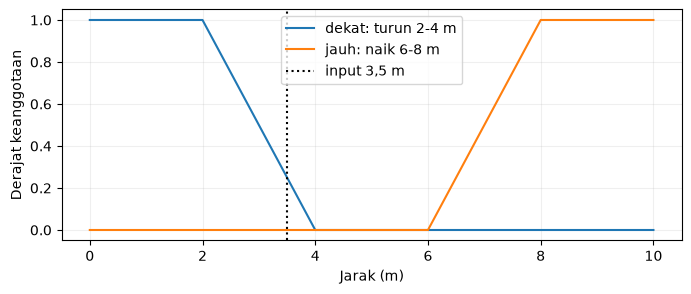

In [4]:
distance_grid = np.linspace(0, 10, 501)
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [linear_down(x, 2, 4) for x in distance_grid], label="dekat: turun 2-4 m")
plt.plot(distance_grid, [linear_up(x, 6, 8) for x in distance_grid], label="jauh: naik 6-8 m")
plt.axvline(3.5, color="black", linestyle=":", label="input 3,5 m")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Ikuti garis vertikal pada 3,5 m sampai bertemu kurva dekat, lalu baca ketinggiannya: 0,25. Kurva jauh masih berada pada sumbu horizontal, sehingga derajatnya 0.

## 1.4 Fungsi Keanggotaan Segitiga dan Trapesium

Selain fungsi linier naik dan turun, dua bentuk fungsi keanggotaan yang banyak digunakan dalam fuzzy logic adalah **fungsi segitiga** dan **fungsi trapesium**. Keduanya dibentuk dari beberapa garis linier, tetapi memiliki cara yang berbeda dalam menentukan nilai yang dianggap paling mewakili suatu himpunan fuzzy.

### Fungsi keanggotaan segitiga

Fungsi keanggotaan **segitiga** memiliki tiga parameter, yaitu $a$, $b$, dan $c$, dengan:

$$
a<b<c.
$$

Ketiga parameter tersebut memiliki arti:

* $a$ = batas kiri, yaitu titik saat derajat keanggotaan mulai naik dari 0;
* $b$ = titik puncak, yaitu nilai yang memiliki derajat keanggotaan maksimum $\mu(x)=1$;
* $c$ = batas kanan, yaitu titik saat derajat keanggotaan kembali menjadi 0.

Secara matematis, fungsi keanggotaan segitiga dapat dituliskan sebagai:

$$
\mu_{\triangle}(x;a,b,c)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x\leq b,\\[8pt]
\dfrac{c-x}{c-b}, & b<x<c,\\[8pt]
0, & x\geq c.
\end{cases}
$$

atau secara ringkas:

$$
\mu_{\triangle}(x;a,b,c)=
\begin{cases}
0, & x\leq a \text{ atau } x\geq c,\\[4pt]
\dfrac{x-a}{b-a}, & a<x\leq b,\\[8pt]
\dfrac{c-x}{c-b}, & b<x<c.
\end{cases}
$$

Bentuk fungsi ini dapat dipahami dalam tiga bagian. Dari $a$ menuju $b$, derajat keanggotaan **naik secara linier** dari 0 menjadi 1. Pada $x=b$, derajat keanggotaan mencapai nilai maksimum:

$$
\mu(b)=1.
$$

Kemudian, dari $b$ menuju $c$, derajat keanggotaan **turun secara linier** dari 1 menjadi 0.

Dengan demikian, fungsi segitiga memiliki **satu nilai yang dianggap paling mewakili suatu label fuzzy**, yaitu nilai $b$.

Sebagai contoh, misalkan kategori **Sedang** direpresentasikan menggunakan fungsi segitiga:

$$
(1,5,9).
$$

Artinya:

* pada $x=1$, derajat keanggotaan adalah 0;
* dari $x=1$ sampai $x=5$, derajat keanggotaan meningkat;
* pada $x=5$, nilai dianggap sepenuhnya **Sedang**, sehingga $\mu_{\text{sedang}}(5)=1$;
* dari $x=5$ sampai $x=9$, derajat keanggotaan menurun;
* pada $x\geq9$, derajat keanggotaan kembali menjadi 0.

---

### Fungsi keanggotaan trapesium

Fungsi keanggotaan **trapesium** merupakan pengembangan dari fungsi segitiga. Perbedaannya adalah fungsi trapesium tidak hanya memiliki satu titik dengan derajat keanggotaan 1, tetapi memiliki **sebuah rentang nilai yang seluruhnya dianggap sepenuhnya memenuhi suatu label fuzzy**.

Fungsi ini memiliki empat parameter:

$$
a<b\leq c<d.
$$

Parameter tersebut memiliki arti:

* $a$ = batas kiri saat derajat keanggotaan mulai naik dari 0;
* $b$ = titik awal derajat keanggotaan penuh;
* $c$ = titik akhir derajat keanggotaan penuh;
* $d$ = batas kanan saat derajat keanggotaan kembali menjadi 0.

Fungsi keanggotaan trapesium dituliskan sebagai:

$$
\mu_{\text{trap}}(x;a,b,c,d)=
\begin{cases}
0, & x\leq a,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[8pt]
1, & b\leq x\leq c,\\[4pt]
\dfrac{d-x}{d-c}, & c<x<d,\\[8pt]
0, & x\geq d.
\end{cases}
$$

atau secara ringkas:

$$
\mu_{\text{trap}}(x;a,b,c,d)=
\begin{cases}
0, & x\leq a \text{ atau } x\geq d,\\[4pt]
\dfrac{x-a}{b-a}, & a<x<b,\\[8pt]
1, & b\leq x\leq c,\\[4pt]
\dfrac{d-x}{d-c}, & c<x<d.
\end{cases}
$$

Fungsi tersebut mempunyai tiga bagian utama:

1. **Daerah naik**, yaitu dari $a$ sampai $b$, ketika derajat keanggotaan meningkat dari 0 menuju 1.
2. **Daerah penuh**, yaitu dari $b$ sampai $c$, ketika semua nilai mempunyai derajat keanggotaan 1.
3. **Daerah turun**, yaitu dari $c$ sampai $d$, ketika derajat keanggotaan menurun dari 1 menuju 0.

### Contoh perhitungan fungsi trapesium

Misalkan kategori jarak **Sedang** direpresentasikan menggunakan fungsi trapesium:

$$
(1,4,6,9).
$$

Maka:

* $x\leq1$ memiliki derajat keanggotaan 0;
* $1<x<4$ merupakan daerah transisi naik;
* $4\leq x\leq6$ merupakan daerah keanggotaan penuh dengan $\mu(x)=1$;
* $6<x<9$ merupakan daerah transisi turun;
* $x\geq9$ memiliki derajat keanggotaan 0.

Dengan demikian, rentang **4–6 meter** dianggap sepenuhnya memenuhi kategori **Sedang**.

Sekarang misalkan jarak yang diamati adalah:

$$
x=3{,}5.
$$

Langkah pertama adalah menentukan posisi $x$. Karena:

$$
1<3{,}5<4,
$$

maka $x=3{,}5$ berada pada **sisi naik** fungsi trapesium. Oleh karena itu, digunakan persamaan:

$$
\mu_{\text{sedang}}(x)
=
\frac{x-a}{b-a}.
$$

Substitusikan $a=1$, $b=4$, dan $x=3{,}5$:

$$
\mu_{\text{sedang}}(3{,}5)
=
\frac{3{,}5-1}{4-1}
=
\frac{2{,}5}{3}
\approx0{,}8333.
$$

Jadi:

$$
\boxed{\mu_{\text{sedang}}(3{,}5)\approx0{,}8333}
$$

Artinya, jarak 3,5 meter memiliki **derajat keanggotaan sekitar 0,83 terhadap kategori Sedang**. Nilai tersebut sudah cukup dekat dengan daerah keanggotaan penuh yang dimulai pada 4 meter.

### Perbedaan segitiga dan trapesium

Perbedaan utama kedua fungsi tersebut terletak pada daerah dengan derajat keanggotaan maksimum.

Pada fungsi **segitiga**, hanya terdapat satu titik yang mempunyai derajat keanggotaan 1:

$$
\mu(b)=1.
$$

Sementara itu, pada fungsi **trapesium**, terdapat sebuah rentang nilai yang memiliki derajat keanggotaan 1:

$$
\mu(x)=1,\qquad b\leq x\leq c.
$$

Oleh karena itu, fungsi segitiga cocok ketika terdapat **satu nilai yang paling mewakili suatu kategori**, sedangkan fungsi trapesium cocok ketika terdapat **rentang nilai yang sama-sama dianggap sepenuhnya mewakili kategori tersebut**.

Dalam contoh jarak di atas, fungsi **Sedang** yang digunakan adalah trapesium $(1,4,6,9)$. Fungsi segitiga $(1,5,9)$ dapat digunakan sebagai bentuk alternatif untuk memahami perbedaannya, tetapi **bukan fungsi keanggotaan Sedang yang digunakan pada contoh tersebut**.

Hal terpenting ketika menghitung fungsi segitiga maupun trapesium adalah selalu menentukan terlebih dahulu **posisi nilai input $x$ terhadap parameter-parameter fungsi**. Setelah mengetahui posisi tersebut, pilih hanya bagian persamaan yang sesuai.


### Contoh penerapan

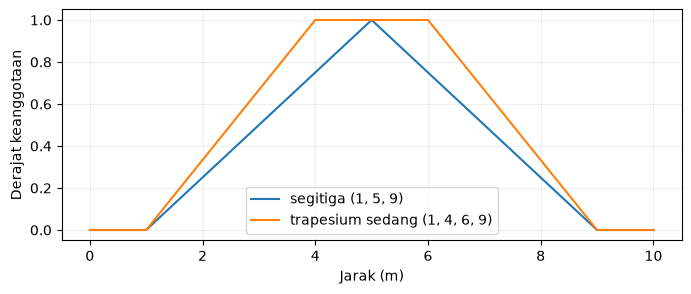

,jarak (m),segitiga,trapesium
0,1.0,0.000,0.000000
1,3.5,0.625,0.833333
2,4.0,0.750,1.000000
3,5.0,1.000,1.000000
4,6.0,0.750,1.000000
5,9.0,0.000,0.000000


In [5]:
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [triangular(x, 1, 5, 9) for x in distance_grid], label="segitiga (1, 5, 9)")
plt.plot(distance_grid, [trapezoidal(x, 1, 4, 6, 9) for x in distance_grid], label="trapesium sedang (1, 4, 6, 9)")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
display(pd.DataFrame([
    {"jarak (m)": x, "segitiga": triangular(x, 1, 5, 9),
     "trapesium": trapezoidal(x, 1, 4, 6, 9)}
    for x in [1, 3.5, 4, 5, 6, 9]
]))

Pada 4 dan 6 m, trapesium bernilai 1, sedangkan segitiga bernilai 0,75. Memilih bentuk fungsi berarti memilih definisi label. Titik patah perlu ditentukan dari pengetahuan masalah atau data, kemudian diuji kesesuaiannya.

---
## 1.5 Pengayaan: kurva S dan phi

**Kurva S** pada modul ini adalah fungsi kuadratik bertingkat yang dinamai `sigmoid`, dengan $b=(a+c)/2$. Derajat berubah dari 0 menuju 1 dan bernilai 0,5 di titik tengah $b$.

$$S(x;a,b,c)=\begin{cases}0,&x\le a\\2\left(\frac{x-a}{c-a}\right)^2,&a<x\le b\\1-2\left(\frac{c-x}{c-a}\right)^2,&b<x<c\\1,&x\ge c.\end{cases}$$

**Phi** membentuk lonceng: naik halus menuju satu puncak, lalu turun halus. Dalam `phi(x, a, b, c)`, parameter $a$ berarti tepi kiri, $b$ puncak, dan $c$ tepi kanan:

$$\mu_{\phi}(x;a,b,c)=\begin{cases}S\left(x;a,\frac{a+b}{2},b\right),&x\le b\\1-S\left(x;b,\frac{b+c}{2},c\right),&x>b.\end{cases}$$

Catatan sumber: parameter phi pada halaman 29 memakai pusat dan lebar dengan notasi berbeda. Cabang kanan yang tercetak juga belum memakai komplemen; di sini digunakan $1-S$ agar sisi kanan menurun sesuai gambar lonceng. Kurva S ini berbeda rumus dari fungsi logistik, dan phi ini bukan fungsi Gaussian yang juga diperlihatkan pada halaman 22.

### Contoh penerapan

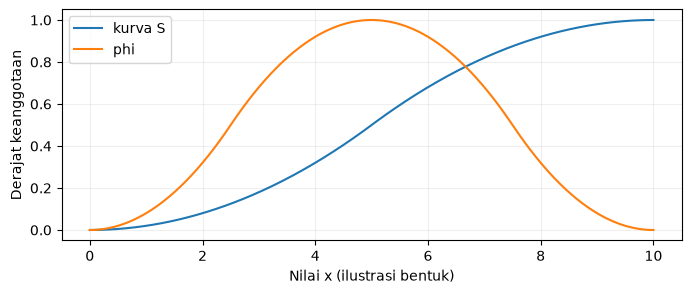

S pada 0, 5, 10: [0.0, 0.5, 1.0]
Phi pada 0, 5, 10: [0.0, 1.0, 0.0]


In [6]:
plt.figure(figsize=(8, 3))
plt.plot(distance_grid, [sigmoid(x, 0, 5, 10) for x in distance_grid], label="kurva S")
plt.plot(distance_grid, [phi(x, 0, 5, 10) for x in distance_grid], label="phi")
plt.xlabel("Nilai x (ilustrasi bentuk)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
print("S pada 0, 5, 10:", [sigmoid(x, 0, 5, 10) for x in (0, 5, 10)])
print("Phi pada 0, 5, 10:", [phi(x, 0, 5, 10) for x in (0, 5, 10)])

Kurva S memberi [0; 0,5; 1], sedangkan phi memberi [0; 1; 0]. Keenam fungsi yang sudah digunakan tersedia di `membership.py`: `linear_up`, `linear_down`, `triangular`, `trapezoidal`, `sigmoid`, dan `phi`. Setiap pemanggilan menerima satu nilai input dan mengembalikan satu derajat antara 0 dan 1.

## 1.6 Fuzzifikasi: Dari Nilai Crisp Menjadi Derajat Keanggotaan

**Fuzzifikasi** (*fuzzification*) adalah proses mengubah sebuah nilai input yang bersifat **crisp** menjadi satu atau lebih **derajat keanggotaan fuzzy**.

Nilai **crisp** adalah nilai pengukuran yang pasti, misalnya:

$$
x=3{,}5\text{ meter}.
$$

Dalam sistem fuzzy, nilai tersebut tidak langsung dimasukkan ke dalam satu kategori saja. Sebaliknya, sistem menghitung seberapa kuat nilai tersebut menjadi anggota dari setiap himpunan fuzzy yang telah didefinisikan, misalnya **Dekat**, **Sedang**, dan **Jauh**.

Dengan demikian, fuzzifikasi dapat dipandang sebagai proses:

$$
\boxed{
\text{nilai crisp}
\longrightarrow
\text{sekumpulan derajat keanggotaan}
}
$$

Secara umum, fuzzifikasi dilakukan melalui beberapa langkah:

1. menentukan **variabel input** dan domain nilainya;
2. menentukan **himpunan fuzzy atau label linguistik** untuk variabel tersebut;
3. menentukan **fungsi keanggotaan** untuk setiap label;
4. memasukkan nilai crisp hasil pengukuran ke setiap fungsi keanggotaan;
5. menyimpan seluruh derajat keanggotaan yang dihasilkan untuk digunakan pada tahap inferensi fuzzy.

### Contoh fuzzifikasi variabel jarak

Misalkan variabel **Jarak** memiliki tiga label linguistik:

* **Dekat** (*small*),
* **Sedang** (*medium*),
* **Jauh** (*large*).

Fungsi keanggotaan yang digunakan adalah sebagai berikut:

| Label             | Fungsi                       | Interpretasi                                                              |
| ----------------- | ---------------------------- | ------------------------------------------------------------------------- |
| Dekat / *small*   | `linear_down(x, 2, 4)`       | Keanggotaan penuh hingga 2 m, kemudian menurun, dan menjadi 0 mulai 4 m   |
| Sedang / *medium* | `trapezoidal(x, 1, 4, 6, 9)` | Naik pada 1–4 m, penuh pada 4–6 m, kemudian turun pada 6–9 m              |
| Jauh / *large*    | `linear_up(x, 6, 8)`         | Keanggotaan 0 hingga 6 m, kemudian meningkat, dan menjadi penuh mulai 8 m |

Misalkan diperoleh hasil pengukuran:

$$
x=3{,}5\text{ m}.
$$

Nilai tersebut kemudian dimasukkan ke **setiap fungsi keanggotaan**.

#### 1. Derajat keanggotaan Dekat

Untuk kategori **Dekat**, digunakan fungsi linier turun dari 2 m sampai 4 m. Karena:

$$
2<3{,}5<4,
$$

maka:

$$
\mu_{\text{dekat}}(3{,}5)
=
\frac{4-3{,}5}{4-2}
=
\frac{0{,}5}{2}
=
0{,}25.
$$

Jadi:

$$
\mu_{\text{dekat}}(3{,}5)=0{,}25.
$$

#### 2. Derajat keanggotaan Sedang

Kategori **Sedang** menggunakan fungsi trapesium:

$$
(1,4,6,9).
$$

Karena:

$$
1<3{,}5<4,
$$

nilai tersebut berada pada bagian naik fungsi trapesium. Maka:

$$
\mu_{\text{sedang}}(3{,}5)
=
\frac{3{,}5-1}{4-1}
=
\frac{2{,}5}{3}
\approx0{,}8333.
$$

Jadi:

$$
\mu_{\text{sedang}}(3{,}5)\approx0{,}8333.
$$

#### 3. Derajat keanggotaan Jauh

Kategori **Jauh** mulai mengalami kenaikan keanggotaan pada 6 m. Karena:

$$
3{,}5<6,
$$

maka:

$$
\mu_{\text{jauh}}(3{,}5)=0.
$$

### Hasil fuzzifikasi

Seluruh hasil tersebut dapat disusun sebagai sebuah vektor derajat keanggotaan:

$$
\boldsymbol{\mu}(3{,}5)
=
[
\mu_{\text{dekat}}(3{,}5),
\mu_{\text{sedang}}(3{,}5),
\mu_{\text{jauh}}(3{,}5)
].
$$

Sehingga:

$$
\boxed{
\boldsymbol{\mu}(3{,}5)
=
[0{,}25,\;0{,}8333,\;0]
}
$$

Hasil tersebut dapat dibaca sebagai:

* jarak 3,5 m memiliki derajat keanggotaan **0,25 sebagai Dekat**;
* jarak 3,5 m memiliki derajat keanggotaan **0,8333 sebagai Sedang**;
* jarak 3,5 m memiliki derajat keanggotaan **0 sebagai Jauh**.

![Fuzzifikasi jarak pada halaman 24 Fuzzy Logic complete.pdf](img/complete-24-fuzzifikasi.png)


### Contoh penerapan

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat pada 3,5 m, dtype: float64

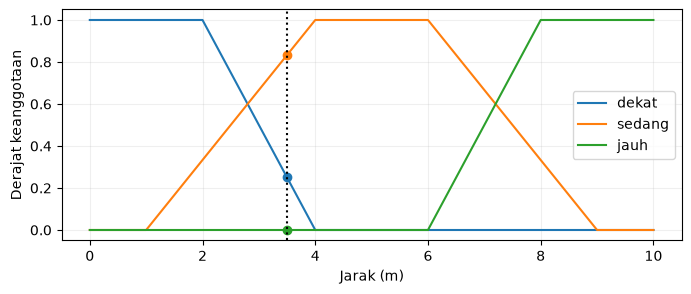

In [7]:
def fuzzify_distance(distance):
    """Hitung derajat jarak pada domain praktikum 0 sampai 10 meter."""
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

mu_distance = fuzzify_distance(3.5)
display(pd.Series(mu_distance, name="derajat pada 3,5 m"))
plt.figure(figsize=(8, 3))
for label in mu_distance:
    plt.plot(distance_grid, [fuzzify_distance(x)[label] for x in distance_grid], label=label)
    plt.scatter([3.5], [mu_distance[label]])
plt.axvline(3.5, color="black", linestyle=":")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 1.7 Basis Pengetahuan dan Operator Aturan

Setelah proses **fuzzifikasi**, derajat keanggotaan yang diperoleh digunakan untuk mengevaluasi sekumpulan aturan fuzzy. Kumpulan aturan ini merupakan bagian dari **basis pengetahuan** (*knowledge base*) pada sistem fuzzy.

Aturan fuzzy umumnya ditulis dalam bentuk:

$$
\text{IF kondisi THEN aksi}
$$

Bagian setelah **IF** disebut **anteseden** (*antecedent*), sedangkan bagian setelah **THEN** disebut **konsekuen** (*consequent*).

Sebagai contoh, digunakan tiga aturan berikut:

| Aturan | Anteseden       | Konsekuen             |
| ------ | --------------- | --------------------- |
| R1     | IF jarak Dekat  | THEN kecepatan Rendah |
| R2     | IF jarak Sedang | THEN kecepatan Sedang |
| R3     | IF jarak Jauh   | THEN kecepatan Tinggi |

Aturan R1 dapat dibaca:

> Jika jarak termasuk kategori **Dekat**, maka kecepatan seharusnya **Rendah**.

Dalam fuzzy logic, suatu aturan tidak hanya berada dalam keadaan **aktif** atau **tidak aktif**. Setiap aturan dapat aktif dengan tingkat tertentu, sesuai dengan derajat kebenaran antesedennya.

### Kekuatan aktivasi aturan

Tingkat aktivasi sebuah aturan disebut **kekuatan aktivasi** atau *firing strength*, yang biasanya dilambangkan dengan:

$$
\alpha_i.
$$

Nilai $\alpha_i$ berada pada rentang:

$$
0\leq\alpha_i\leq1.
$$

Semakin besar nilai $\alpha_i$, semakin kuat aturan tersebut diaktifkan oleh input yang diberikan.

Dari proses fuzzifikasi sebelumnya untuk:

$$
x=3{,}5\text{ m},
$$

diperoleh:

$$
\mu_{\text{dekat}}=0{,}25,
$$

$$
\mu_{\text{sedang}}=0{,}8333,
$$

dan

$$
\mu_{\text{jauh}}=0.
$$

Karena ketiga aturan di atas masing-masing hanya memiliki **satu kondisi pada anteseden**, kekuatan aktivasinya langsung sama dengan derajat keanggotaan input yang bersesuaian.

Untuk R1:

$$
\alpha_1
=
\mu_{\text{dekat}}(3{,}5)
=
0{,}25.
$$

Untuk R2:

$$
\alpha_2
=
\mu_{\text{sedang}}(3{,}5)
=
0{,}8333.
$$

Untuk R3:

$$
\alpha_3
=
\mu_{\text{jauh}}(3{,}5)
=
0.
$$

Sehingga:

$$
\boxed{
\alpha_1=0{,}25,\qquad
\alpha_2=0{,}8333,\qquad
\alpha_3=0
}
$$

Artinya, aturan R2 paling kuat diaktifkan, tetapi aturan R1 juga masih aktif dengan tingkat yang lebih rendah. Sementara itu, R3 tidak aktif karena derajat keanggotaan **Jauh** bernilai 0.

Perlu diperhatikan bahwa sistem fuzzy tetap mempertahankan semua aturan yang memiliki nilai aktivasi bukan nol. Dengan demikian, beberapa aturan dapat aktif secara bersamaan.

---

### Aturan dengan beberapa kondisi

Dalam sistem yang lebih kompleks, sebuah aturan dapat memiliki lebih dari satu kondisi.

Contohnya:

$$
\text{IF jarak Dekat AND kecepatan Tinggi THEN rem Kuat}.
$$

Misalkan diperoleh:

$$
\mu_{\text{dekat}}=0{,}25
$$

dan

$$
\mu_{\text{tinggi}}=0{,}8.
$$

Untuk menggabungkan beberapa kondisi tersebut, digunakan **operator fuzzy**. Operator yang umum digunakan adalah **AND**, **OR**, dan **NOT**.

### Operator AND

Operator **AND** digunakan ketika semua kondisi dalam anteseden harus dipertimbangkan secara bersama-sama.

Salah satu operator yang paling umum digunakan adalah fungsi minimum:

$$
\mu_{A\cap B}
=
\min(\mu_A,\mu_B).
$$

Untuk:

$$
\mu_A=0{,}25
$$

dan

$$
\mu_B=0{,}8,
$$

maka:

$$
\mu_{A\cap B}
=
\min(0{,}25,0{,}8)
=
0{,}25.
$$

Sehingga kekuatan aktivasi aturan menjadi:

$$
\boxed{\alpha=0{,}25}
$$

Intuisinya, sebuah aturan dengan operator AND dibatasi oleh **kondisi yang paling lemah**.

Sebagai contoh:

$$
\text{IF jarak Dekat AND kecepatan Tinggi}
$$

hanya dapat aktif sebesar 0,25 meskipun kondisi **kecepatan Tinggi** memiliki derajat 0,8, karena kondisi **jarak Dekat** hanya terpenuhi sebesar 0,25.

---

### Operator OR

Operator **OR** digunakan ketika cukup salah satu kondisi terpenuhi untuk mengaktifkan aturan.

Operator yang umum digunakan adalah fungsi maksimum:

$$
\mu_{A\cup B}
=
\max(\mu_A,\mu_B).
$$

Untuk:

$$
\mu_A=0{,}25
$$

dan

$$
\mu_B=0{,}8,
$$

maka:

$$
\mu_{A\cup B}
=
\max(0{,}25,0{,}8)
=
0{,}8.
$$

Sehingga:

$$
\boxed{\alpha=0{,}8}
$$

Intuisinya, pada operator OR, kondisi dengan derajat keanggotaan terbesar sudah cukup untuk memberikan aktivasi yang kuat.

---

### Operator NOT

Operator **NOT** digunakan untuk menyatakan negasi atau kebalikan dari sebuah kondisi fuzzy.

Operator komplemen yang umum digunakan adalah:

$$
\mu_{\neg A}=1-\mu_A.
$$

Jika:

$$
\mu_A=0{,}25,
$$

maka:

$$
\mu_{\neg A}
=
1-0{,}25
=
0{,}75.
$$

Sehingga:

$$
\boxed{\mu_{\text{NOT }A}=0{,}75}
$$

Artinya, apabila suatu nilai memiliki derajat keanggotaan 0,25 terhadap himpunan $A$, maka derajat keanggotaannya terhadap **NOT A** adalah 0,75.

---

### Ringkasan operator fuzzy

Operator yang digunakan dapat dirangkum sebagai berikut:

| Operator | Operasi             | Contoh untuk 0,25 dan 0,8 | Interpretasi                                     |
| -------- | ------------------- | ------------------------: | ------------------------------------------------ |
| AND      | $\min(\mu_A,\mu_B)$ |                  $0{,}25$ | Dibatasi oleh kondisi yang paling lemah          |
| OR       | $\max(\mu_A,\mu_B)$ |                   $0{,}8$ | Cukup salah satu kondisi memiliki derajat tinggi |
| NOT      | $1-\mu_A$           |                  $0{,}75$ | Menghasilkan derajat komplemen                   |

Operator **min**, **max**, dan **komplemen** di atas merupakan pilihan yang sangat umum pada sistem fuzzy, khususnya pada inferensi Mamdani. Namun, operator fuzzy tidak terbatas pada bentuk tersebut. Dalam sistem tertentu, AND misalnya dapat menggunakan perkalian (*product*) dan OR dapat menggunakan operator lain sesuai desain sistem.

Hal utama yang perlu dipahami adalah bahwa **fuzzifikasi menghasilkan derajat keanggotaan**, sedangkan **evaluasi aturan menggunakan derajat tersebut untuk menentukan kekuatan aktivasi setiap aturan**.

Alur prosesnya dapat diringkas sebagai:

$$
\boxed{
\text{Input crisp}
\rightarrow
\text{Fuzzifikasi}
\rightarrow
\text{Derajat keanggotaan}
\rightarrow
\text{Evaluasi aturan}
\rightarrow
\text{Firing strength }(\alpha)
}
$$

Nilai $\alpha$ inilah yang selanjutnya digunakan untuk menentukan seberapa besar konsekuen setiap aturan berkontribusi terhadap hasil inferensi fuzzy.


### Contoh penerapan

In [8]:
rule_strengths = {
    "R1: kecepatan rendah": mu_distance["dekat"],
    "R2: kecepatan sedang": mu_distance["sedang"],
    "R3: kecepatan tinggi": mu_distance["jauh"],
}
display(pd.Series(rule_strengths, name="kekuatan aturan"))
print("Contoh AND:", min(0.25, 0.8))
print("Contoh OR:", max(0.25, 0.8))
print("Contoh NOT:", 1 - 0.25)

R1: kecepatan rendah    0.250000
R2: kecepatan sedang    0.833333
R3: kecepatan tinggi    0.000000
Name: kekuatan aturan, dtype: float64

Contoh AND: 0.25
Contoh OR: 0.8
Contoh NOT: 0.75


R1 dan R2 aktif bersamaan, sedangkan R3 tidak aktif. Nilai 0,8333 adalah kekuatan aturan kecepatan sedang; angka itu bukan kecepatan dalam m/s. Kita masih perlu mendefinisikan himpunan keluaran dan menggabungkan kontribusi aturan.

## 1.8 Menghubungkan Konsep Menjadi Sistem Inferensi Fuzzy

Setelah memahami fungsi keanggotaan, fuzzifikasi, aturan fuzzy, serta kekuatan aktivasi (*firing strength*), seluruh konsep tersebut dapat digabungkan menjadi sebuah **sistem inferensi fuzzy** (*Fuzzy Inference System* atau FIS).

Sistem inferensi fuzzy menerima **input crisp**, mengubahnya menjadi representasi fuzzy, mengevaluasi aturan IF–THEN, menggabungkan hasil aturan, lalu menghasilkan kembali sebuah **output crisp**.

Secara umum, sistem inferensi fuzzy terdiri dari beberapa komponen utama:

| Komponen                                 | Tugas                                                                                                      | Contoh                                              |
| ---------------------------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------------------------------------- |
| **Fuzzifier**                            | Mengubah input crisp menjadi derajat keanggotaan pada setiap himpunan fuzzy                                | $3{,}5$ m $\rightarrow [0{,}25;\ 0{,}8333;\ 0]$     |
| **Basis pengetahuan** (*knowledge base*) | Menyimpan definisi himpunan fuzzy, fungsi keanggotaan, dan aturan IF–THEN                                  | IF jarak Dekat THEN kecepatan Rendah                |
| **Mesin inferensi** (*inference engine*) | Menghitung kekuatan aktivasi aturan dan menentukan kontribusi masing-masing aturan terhadap keluaran fuzzy | R1 aktif sebesar $0{,}25$ dan R2 sebesar $0{,}8333$ |
| **Defuzzifier**                          | Mengubah hasil fuzzy akhir menjadi satu nilai crisp                                                        | Rekomendasi kecepatan, misalnya dalam m/s           |

## Latihan Soal

Kerjakan latihan secara berurutan: pemahaman konsep, perhitungan fuzzifikasi, lalu analisis perubahan model. Tuliskan alasan dan langkah hitung sebelum memeriksanya dengan Python. Gunakan sel kosong untuk jawaban atau kode; untuk jawaban naratif, ubah jenis sel menjadi Markdown. Buka hint jika memerlukan petunjuk.

### Soal 1 - Pemahaman konsep

Pada jarak 3,5 m, model memberikan derajat dekat = 0,25 dan sedang ≈ 0,8333.

1. Jelaskan arti kedua derajat tersebut dengan kalimat Anda sendiri. Hubungkan penjelasan dengan posisi input pada grafik fungsi keanggotaan.
2. Seorang mahasiswa menganggap hasil itu salah karena jumlah derajatnya melebihi 1. Apakah Anda setuju? Berikan alasan berdasarkan definisi fungsi keanggotaan.
3. Bandingkan pernyataan "derajat dekat adalah 0,25" dengan "peluang jarak kurang dari 3 m adalah 25%". Informasi apa yang dijelaskan oleh masing-masing pernyataan?

In [9]:
# Soal 1 - cek angka yang ada di soal dulu
jarak = 3.5
dekat = linear_down(jarak, 2, 4)  # 2 < 3.5 < 4 jadi pakai (4-x)/(4-2)
sedang = trapezoidal(jarak, 1, 4, 6, 9)  # 1 < 3.5 < 4 jadi sisi naik (x-1)/(4-1)
jauh = linear_up(jarak, 6, 8)  # 3.5 < 6 jadi masih 0

print("dekat =", dekat)  # harusnya 0.25
print("sedang =", sedang)  # harusnya 0.8333
print("jauh =", jauh)
print("jumlah =", dekat + sedang + jauh)

# cek manual biar yakin:
print("manual dekat:", (4 - 3.5) / (4 - 2))
print("manual sedang:", (3.5 - 1) / (4 - 1))


dekat = 0.25
sedang = 0.8333333333333334
jauh = 0.0
jumlah = 1.0833333333333335
manual dekat: 0.25
manual sedang: 0.8333333333333334


**Jawaban Soal 1 (pemahaman konsep)**

1. Artinya 0,25 itu kecocokan jarak 3,5 m sama konsep "dekat" cuma 0,25 (kecil, karena 3,5 udah hampir keluar dari bahu dekat yang habis di 4 m). Sedangkan 0,8333 artinya kecocokannya sama konsep "sedang" besar, karena 3,5 udah mepet ke daerah penuh sedang yang mulai di 4 m. Kalau dilihat di grafik, garis vertikal x = 3,5 motong kurva merah (dekat) di ketinggian 0,25, terus motong kurva hijau (sedang) di ketinggian 0,83. Jadi satu input bisa nempel ke dua label sekaligus, tinggal dibaca tingginya.

2. Nggak setuju kalau dianggap salah. Tiap fungsi keanggotaan itu nilainya mandiri, syaratnya cuma tiap output harus di [0,1], nggak ada syarat jumlahnya harus 1. Di materi juga ditulis jumlahnya boleh 1,0833 dan tetap sah. Jadi beda sama probabilitas yang totalnya harus 1.

3. "Derajat dekat 0,25" itu ngomongin kecocokan: jaraknya jelas 3,5 m (pasti), yang bertingkat itu seberapa cocok 3,5 m sama definisi dekat yang kita bikin. Sedangkan "peluang jarak < 3 m adalah 25%" itu ngomongin ketidakpastian kejadian: jaraknya belum pasti, ada kemungkinan 25% kejadiannya terjadi. Yang satu nilai kecocokan (fuzzy), yang satu nilai kemungkinan (probabilitas). Jadi nggak bisa disamain.


<details>
<summary>Klik untuk melihat hint</summary>

Perhatikan apa yang ditunjukkan sumbu horizontal dan vertikal pada grafik. Tinjau kembali syarat nilai keluaran setiap fungsi keanggotaan, lalu bedakan syarat itu dari asumsi tentang jumlah antarlabel. Untuk bagian terakhir, tanyakan apakah angka tersebut menilai kecocokan sebuah input atau ketidakpastian suatu kejadian.

</details>

### Soal 2 - Fuzzifikasi dan aktivasi aturan

![practice](img/Practice-Fuzzy-Logic.png)

| Label | Fungsi keanggotaan |
|---|---|
| Dekat | `linear_down(x, 2, 4)` |
| Sedang | `trapezoidal(x, 1, 4, 6, 9)` |
| Jauh | `linear_up(x, 6, 8)` |

1. Untuk setiap jarak, tentukan cabang rumus yang berlaku dan hitung ketiga derajat secara manual.
2. Susun tabel dengan kolom jarak, derajat dekat, derajat sedang, dan derajat jauh.
3. Gunakan aturan R1: dekat → kecepatan rendah; R2: sedang → kecepatan sedang; R3: jauh → kecepatan tinggi. Tentukan aturan aktif dan kekuatan aktivasinya untuk setiap jarak.
4. Verifikasi tabel menggunakan `fuzzify_distance`. Jika hasil berbeda, periksa kembali pemilihan cabang rumus dan pembulatannya.

In [10]:
# Soal 2 - fuzzifikasi + aktivasi aturan
# fungsinya sama kayak di materi
def fuzzify_distance(x):
    return {
        "dekat": linear_down(x, 2, 4),
        "sedang": trapezoidal(x, 1, 4, 6, 9),
        "jauh": linear_up(x, 6, 8),
    }

# saya ambil 6 jarak biar semua daerah kecover:
# 0 (dekat penuh), 2.5 (transisi), 3.5 (contoh soal),
# 5 (sedang penuh), 7 (sedang-jauh), 10 (jauh penuh)
daftar_jarak = [0, 2.5, 3.5, 5, 7, 10]

# 1) hitung manual per cabang biar kelihatan cabangnya
print("Hitung manual:")
print("2.5 -> dekat:", (4-2.5)/(4-2), " sedang:", (2.5-1)/(4-1), " jauh: 0")
print("3.5 -> dekat:", (4-3.5)/(4-2), " sedang:", (3.5-1)/(4-1), " jauh: 0")
print("7 -> dekat: 0, sedang:", (9-7)/(9-6), " jauh:", (7-6)/(8-6))

# 2) bikin tabel
rows = []
for x in daftar_jarak:
    d = fuzzify_distance(x)
    rows.append({"jarak": x, "dekat": round(d["dekat"], 4), "sedang": round(d["sedang"], 4), "jauh": round(d["jauh"], 4)})
df = pd.DataFrame(rows)
display(df)

# 3) aktivasi aturan: R1=dekat->rendah, R2=sedang->sedang, R3=jauh->tinggi
# karena satu syarat doang, alpha = derajatnya langsung
df_alpha = df.copy()
df_alpha["R1 (rendah)"] = df_alpha["dekat"]
df_alpha["R2 (sedang)"] = df_alpha["sedang"]
df_alpha["R3 (tinggi)"] = df_alpha["jauh"]
display(df_alpha[["jarak", "R1 (rendah)", "R2 (sedang)", "R3 (tinggi)"]])

# 4) verifikasi: harusnya sama persis sama fungsi
for x in daftar_jarak:
    d = fuzzify_distance(x)
    assert abs(d["dekat"] - linear_down(x, 2, 4)) < 1e-9
    assert abs(d["sedang"] - trapezoidal(x, 1, 4, 6, 9)) < 1e-9
    assert abs(d["jauh"] - linear_up(x, 6, 8)) < 1e-9
print("udah dicek, sama semua sama fuzzify_distance")

# yang aktif:
# x=0: cuma R1. x=2.5: R1+R2. x=3.5: R1+R2 (R2 paling kuat).
# x=5: cuma R2. x=7: R2+R3. x=10: cuma R3.


Hitung manual:
2.5 -> dekat: 0.75  sedang: 0.5  jauh: 0
3.5 -> dekat: 0.25  sedang: 0.8333333333333334  jauh: 0
7 -> dekat: 0, sedang: 0.6666666666666666  jauh: 0.5


,jarak,dekat,sedang,jauh
0,0.0,1.00,0.0000,0.0
1,2.5,0.75,0.5000,0.0
2,3.5,0.25,0.8333,0.0
3,5.0,0.00,1.0000,0.0
4,7.0,0.00,0.6667,0.5
5,10.0,0.00,0.0000,1.0


,jarak,R1 (rendah),R2 (sedang),R3 (tinggi)
0,0.0,1.00,0.0000,0.0
1,2.5,0.75,0.5000,0.0
2,3.5,0.25,0.8333,0.0
3,5.0,0.00,1.0000,0.0
4,7.0,0.00,0.6667,0.5
5,10.0,0.00,0.0000,1.0


udah dicek, sama semua sama fuzzify_distance


**Catatan Soal 2**

Cara bacanya: tentuin dulu posisi x terhadap titik patah, baru pilih rumus. Misal x = 2,5 itu ada di sisi turun dekat (2 < 2,5 < 4) jadi pakai (4-x)/2 = 0,75, terus ada di sisi naik sedang (1 < 2,5 < 4) jadi pakai (x-1)/3 = 0,5, dan masih di bawah 6 jadi jauhnya 0. Berlaku sama buat jarak lain, tinggal lihat ada di daerah datar, naik, atau turun. Hasil tabel di atas udah diverifikasi pakai `fuzzify_distance`, jadi kalau beda berarti kemarin salah pilih cabang atau salah bulatin.


<details>
<summary>Klik untuk melihat hint</summary>

Tandai setiap input pada sumbu jarak dan bandingkan posisinya dengan titik patah fungsi. Tentukan apakah input berada di bagian datar, sisi naik, atau sisi turun sebelum melakukan substitusi. Setelah memperoleh derajat, telusuri label pada anteseden masing-masing aturan. Setiap aturan pada soal ini hanya memiliki satu syarat.

</details>

### Soal 3 - Pengaruh perubahan parameter

Perancang mengubah fungsi dekat dari `linear_down(x, 2, 4)` menjadi `linear_down(x, 2, 5)`. Fungsi sedang, fungsi jauh, dan seluruh aturan tetap sama.

1. Prediksi pengaruh perubahan tersebut terhadap derajat dekat pada jarak 3,5 m. Tuliskan alasan sebelum menghitung.
2. Hitung derajat dekat dengan parameter lama dan baru, lalu bandingkan kekuatan aktivasi R1.
3. Gambarkan kedua fungsi dekat pada domain 0-6 m. Identifikasi bagian domain yang berubah dan yang tetap sama.
4. Apakah perubahan kekuatan R1 saja sudah cukup untuk menentukan angka kecepatan akhir? Jelaskan informasi atau tahap perhitungan yang masih perlu Anda periksa.

dekat lama (2,4): 0.25
dekat baru (2,5): 0.5
R1 lama = 0.25  R1 baru = 0.5  (naik 2x lipat)


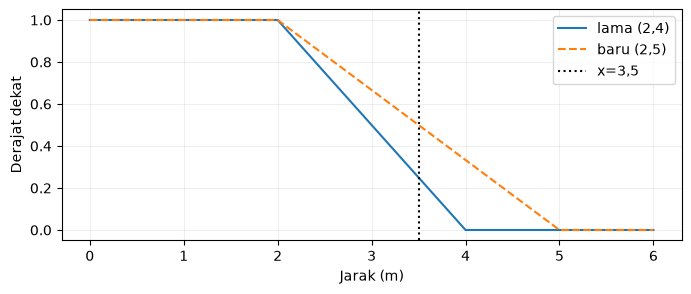

x=0: lama=1.000 baru=1.000
x=1: lama=1.000 baru=1.000
x=2: lama=1.000 baru=1.000
x=3.5: lama=0.250 baru=0.500
x=4: lama=0.000 baru=0.333
x=5: lama=0.000 baru=0.000
x=6: lama=0.000 baru=0.000


In [11]:
# Soal 3 - dekat digeser dari (2,4) jadi (2,5)
# Prediksi saya: derajat dekat di 3.5 pasti naik, karena transisinya lebih panjang
# (penyebut 3 bukan 2), jadi di titik yang sama nilainya lebih tinggi.
x = 3.5
lama = linear_down(x, 2, 4)  # (4-3.5)/2 = 0.25
baru = linear_down(x, 2, 5)  # (5-3.5)/3 = 0.5
print("dekat lama (2,4):", lama)
print("dekat baru (2,5):", baru)
print("R1 lama =", lama, " R1 baru =", baru, " (naik 2x lipat)")

# gambar kedua fungsi di domain 0-6 m
grid = np.linspace(0, 6, 301)
plt.figure(figsize=(8, 3))
plt.plot(grid, [linear_down(v, 2, 4) for v in grid], label="lama (2,4)")
plt.plot(grid, [linear_down(v, 2, 5) for v in grid], label="baru (2,5)", linestyle="--")
plt.axvline(3.5, color="black", linestyle=":", label="x=3,5")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat dekat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# cek daerah yang berubah vs tetap
for v in [0, 1, 2, 3.5, 4, 5, 6]:
    print(f"x={v}: lama={linear_down(v,2,4):.3f} baru={linear_down(v,2,5):.3f}")


**Jawaban Soal 3**

Terbukti prediksinya bener: di 3,5 m naik dari 0,25 jadi 0,5. Dari grafik kelihatan daerah 0-2 m tetap sama (sama-sama 1), daerah >= 5 m tetap sama (sama-sama 0), yang berubah itu 2-5 m: kurva baru turunnya lebih landai. R1 jadi aktifnya lebih kuat.

Tapi R1 doang nggak cukup buat nentuin kecepatan akhir. Masih harus lihat R2 (sedang, 0,8333, nggak berubah) sama R3 (jauh, 0), terus bikin himpunan output kecepatan (rendah/sedang/tinggi), dipotong pakai alpha (implikasi), digabung pakai max (agregasi), baru dicentroid jadi angka m/s. Alpha itu satuannya derajat (nggak bersatuan), bukan m/s. Jadi tanpa tahap implikasi-agregasi-defuzzifikasi nggak bisa tahu kecepatannya berapa.


<details>
<summary>Klik untuk melihat hint</summary>

Parameter kedua pada fungsi linier turun menunjukkan akhir transisi. Buat sketsa dengan menandai awal dan akhir transisi pada kedua kurva, lalu gunakan rumus umum fungsi linier turun. Untuk menafsirkan pengaruhnya pada sistem, telusuri alur FIS dari evaluasi aturan sampai keluaran crisp dan perhatikan satuan setiap hasil antara.

</details>

# 02. Model Mamdani

## Setup

Jalankan sel ini lebih dahulu. Enam fungsi keanggotaan diperkenalkan di Notebook 01 dan disimpan satu kali pada `membership.py` agar notebook berikutnya memakai implementasi yang sama.

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.13.7
Membership module: /Users/noir/Tugas Kuliah dan Belajar/Semester 3/KK/Kecerdasan-Komputasional/Tugas Praktikum 4/membership.py


## 2.1 Overview Fuzzy Logic: Mamdani

**Mamdani Fuzzy Inference System** adalah metode inferensi fuzzy yang menggunakan **himpunan fuzzy sebagai konsekuen setiap aturan**. Artinya, ketika sebuah aturan aktif, hasil aturan tersebut bukan langsung berupa satu nilai numerik, melainkan sebuah fungsi keanggotaan pada variabel output yang dimodifikasi sesuai dengan kekuatan aktivasi aturan.

Sebagai contoh:

$$
R_1:
\quad
\text{IF jarak Dekat THEN kecepatan Rendah}.
$$

Jika untuk suatu input diperoleh:

$$
\mu_{\text{dekat}}(x)=0{,}25,
$$

maka kekuatan aktivasi aturan tersebut adalah:

$$
\alpha_1=0{,}25.
$$

Nilai $\alpha_1$ kemudian digunakan untuk menentukan seberapa besar himpunan fuzzy **Kecepatan Rendah** berkontribusi terhadap keluaran.

Dengan metode implikasi MIN, fungsi keanggotaan keluaran aturan tersebut menjadi:

$$
\mu_{R_1}(z)
=
\min
\left(
\alpha_1,
\mu_{\text{rendah}}(z)
\right).
$$

Secara visual, fungsi keanggotaan **Kecepatan Rendah** seolah-olah dipotong (*clipped*) pada tinggi $0{,}25$.

Jika beberapa aturan aktif secara bersamaan, masing-masing aturan menghasilkan himpunan fuzzy keluarannya sendiri. Seluruh keluaran aturan tersebut kemudian **diagregasikan** menjadi satu himpunan fuzzy gabungan. Hasil agregasi inilah yang selanjutnya diubah menjadi satu nilai numerik melalui proses **defuzzifikasi**.

### Tahapan inferensi Mamdani

Proses Mamdani dapat dibagi menjadi lima tahap utama:

| Tahap                  | Yang dilakukan                                                   | Bentuk hasil                           |
| ---------------------- | ---------------------------------------------------------------- | -------------------------------------- |
| **Fuzzifikasi**        | Menghitung derajat keanggotaan input terhadap setiap label fuzzy | Derajat keanggotaan $\mu \in [0,1]$    |
| **Evaluasi anteseden** | Menghitung kekuatan aktivasi setiap aturan                       | *Firing strength* $\alpha_i \in [0,1]$ |
| **Implikasi**          | Menerapkan $\alpha_i$ pada himpunan fuzzy konsekuen              | Himpunan fuzzy keluaran setiap aturan  |
| **Agregasi**           | Menggabungkan keluaran seluruh aturan                            | Satu himpunan fuzzy gabungan           |
| **Defuzzifikasi**      | Mengubah himpunan fuzzy gabungan menjadi satu nilai numerik      | Output crisp                           |

Dengan demikian, alur keseluruhannya adalah:

$$
\boxed{
\text{Input crisp}
\rightarrow
\text{Fuzzifikasi}
\rightarrow
\text{Evaluasi aturan}
\rightarrow
\text{Implikasi}
\rightarrow
\text{Agregasi}
\rightarrow
\text{Defuzzifikasi}
\rightarrow
\text{Output crisp}
}
$$

### Operator yang digunakan

Pada praktikum ini digunakan konfigurasi Mamdani **max–min** dengan operator:

$$
\text{AND}=\min
$$

$$
\text{OR}=\max
$$

$$
\text{Implikasi}=\min
$$

$$
\text{Agregasi}=\max.
$$

Perlu diperhatikan bahwa AND tidak selalu harus menggunakan MIN dan OR tidak selalu harus menggunakan MAX dalam semua sistem fuzzy. Operator tersebut merupakan **pilihan yang digunakan dalam model Mamdani pada praktikum ini**.

Jika sebuah aturan memiliki beberapa kondisi dengan operator AND, misalnya:

$$
\text{IF jarak Dekat AND kecepatan Tinggi THEN rem Kuat},
$$

maka kekuatan aturan dihitung dengan:

$$
\alpha
=
\min
\left(
\mu_{\text{dekat}},
\mu_{\text{tinggi}}
\right).
$$

Jika digunakan OR:

$$
\alpha
=
\max
\left(
\mu_{\text{dekat}},
\mu_{\text{tinggi}}
\right).
$$

Namun, pada contoh yang digunakan dalam praktikum ini, setiap aturan hanya memiliki **satu kondisi pada anteseden**. Oleh karena itu, operator AND dan OR belum diperlukan untuk menghitung firing strength. Nilai $\alpha_i$ langsung sama dengan derajat keanggotaan kondisi pada aturan tersebut.

---

### Rancangan sistem pada praktikum

Pada praktikum ini digunakan satu variabel input, yaitu **Jarak**, dengan domain:

$$
x\in[0,10]\text{ meter}.
$$

Fungsi keanggotaan input meliputi:

* **Dekat**,
* **Sedang**,
* **Jauh**.

Sebagai contoh, untuk:

$$
x=3{,}5\text{ m},
$$

hasil fuzzifikasinya adalah:

$$
\mu_{\text{dekat}}=0{,}25,
$$

$$
\mu_{\text{sedang}}=0{,}8333,
$$

dan

$$
\mu_{\text{jauh}}=0.
$$

Variabel output yang digunakan adalah **Kecepatan**, dengan domain:

$$
z\in[0,30]\text{ m/s}.
$$

Untuk mempelajari proses inferensi Mamdani secara lengkap, digunakan tiga himpunan fuzzy output:

* **Kecepatan Rendah**,
* **Kecepatan Sedang**,
* **Kecepatan Tinggi**.

Basis aturan praktikum didefinisikan sebagai berikut:

| Aturan | Anteseden       | Konsekuen             | Fungsi keanggotaan output                                              |
| ------ | --------------- | --------------------- | ---------------------------------------------------------------------- |
| $R_1$  | IF jarak Dekat  | THEN kecepatan Rendah | Bahu turun: penuh pada kecepatan rendah dan turun hingga 0 pada 15 m/s |
| $R_2$  | IF jarak Sedang | THEN kecepatan Sedang | Segitiga $(5,15,25)$ m/s                                               |
| $R_3$  | IF jarak Jauh   | THEN kecepatan Tinggi | Bahu naik: mulai naik dari 15 m/s dan penuh pada 30 m/s                |

Dengan aturan tersebut:

$$
R_1:
\text{IF jarak Dekat THEN kecepatan Rendah}
$$

$$
R_2:
\text{IF jarak Sedang THEN kecepatan Sedang}
$$

$$
R_3:
\text{IF jarak Jauh THEN kecepatan Tinggi}.
$$

Untuk input $3{,}5$ m, diperoleh:

$$
\alpha_1=0{,}25,
\qquad
\alpha_2=0{,}8333,
\qquad
\alpha_3=0.
$$

Artinya:

* himpunan **Kecepatan Rendah** diaktifkan dengan kekuatan $0{,}25$;
* himpunan **Kecepatan Sedang** diaktifkan dengan kekuatan $0{,}8333$;
* himpunan **Kecepatan Tinggi** tidak aktif.

Setelah proses implikasi, keluaran $R_1$ dan $R_2$ digabungkan menggunakan operator MAX:

$$
\mu_{\text{agg}}(z)
=
\max
\left(
\mu_{R_1}(z),
\mu_{R_2}(z),
\mu_{R_3}(z)
\right).
$$

Hasilnya adalah satu fungsi keanggotaan fuzzy gabungan pada domain kecepatan $[0,30]$ m/s.

Tahap terakhir adalah melakukan **defuzzifikasi**, misalnya dengan metode centroid:

$$
z^*
=
\frac{
\int z\,\mu_{\text{agg}}(z)\,dz
}{
\int \mu_{\text{agg}}(z)\,dz
}.
$$

Nilai $z^*$ merupakan rekomendasi kecepatan akhir dalam bentuk **crisp**.

### Catatan tentang rancangan praktikum

Parameter fungsi keanggotaan output dan satuan kecepatan dalam m/s pada bagian ini digunakan sebagai **rancangan ilustratif untuk praktikum**. Parameter tersebut tidak dimaksudkan sebagai spesifikasi pengendali kendaraan nyata.

Tujuan utama contoh ini adalah memperlihatkan secara jelas bagaimana:

$$
\boxed{
\text{input}
\rightarrow
\text{derajat keanggotaan}
\rightarrow
\text{aktivasi aturan}
\rightarrow
\text{himpunan fuzzy output}
\rightarrow
\text{agregasi}
\rightarrow
\text{nilai crisp}
}
$$

Setiap tahap pada bagian berikut akan menampilkan hasil perhitungan antara sehingga nilai output akhir dapat ditelusuri kembali hingga ke input, fungsi keanggotaan, dan aturan yang menghasilkannya.

---
## 2.2 Langkah 1: fuzzifikasi input

### Penjelasan

Gunakan kembali fungsi dekat $(2,4)$, sedang $(1,4,6,9)$, dan jauh $(6,8)$. Pada $x=3{,}5$ m:

$$\mu_{\text{dekat}}=\frac{4-3{,}5}{4-2}=0{,}25,\quad
\mu_{\text{sedang}}=\frac{3{,}5-1}{4-1}=\frac56,\quad
\mu_{\text{jauh}}=0.$$

Fungsi `fuzzify_distance` mengembalikan kamus derajat agar label dan nilainya mudah dibaca. Fuzzifikasi hanya menggunakan fungsi **input**; fungsi output kecepatan baru digunakan pada tahap implikasi.

### Contoh penerapan

In [2]:
def fuzzify_distance(distance):
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

distance = 3.5
input_degrees = fuzzify_distance(distance)
display(pd.Series(input_degrees, name="derajat input"))

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat input, dtype: float64

Nilai sedang disimpan sebagai 5/6 ≈ 0,833333, sehingga pembulatan tampilan tidak mengurangi ketelitian langkah berikutnya. Dua derajat yang tidak nol akan mengaktifkan dua aturan.

---
## 2.3 Langkah 2: evaluasi aturan

Kekuatan aturan $\alpha_i$ dihitung dari **anteseden**. Dengan satu syarat per aturan, kita memperoleh $\alpha_1=0{,}25$, $\alpha_2=5/6$, dan $\alpha_3=0$.

Untuk memahami aturan dengan dua syarat, R1 memakai AND dan R2 memakai OR. Prinsipnya adalah:

$$\alpha_{\mathrm{AND}}=\min(\mu_A(x_1),\mu_B(x_2)),\qquad
\alpha_{\mathrm{OR}}=\max(\mu_A(x_1),\mu_B(x_2)).$$

Sebagai ilustrasi, derajat 0,75 dan 0,5 menghasilkan AND = 0,5; derajat 0,25 dan 2/3 menghasilkan OR = 2/3. Operator diterapkan pada **derajat**, bukan langsung pada angka pengukuran $x_1$ dan $x_2$.

Aturan dengan $\alpha_i=0$ tidak menyumbang keluaran. Aturan lain tetap diproses bersama, meskipun ada satu aturan yang lebih kuat.

### Contoh penerapan

In [3]:
rules = [
    {"aturan": "R1", "input": "dekat", "output": "rendah"},
    {"aturan": "R2", "input": "sedang", "output": "sedang"},
    {"aturan": "R3", "input": "jauh", "output": "tinggi"},
]
strengths = np.array([input_degrees[rule["input"]] for rule in rules])
display(pd.DataFrame(rules).assign(alpha=strengths))

,aturan,input,output,alpha
0,R1,dekat,rendah,0.250000
1,R2,sedang,sedang,0.833333
2,R3,jauh,tinggi,0.000000


R2 paling kuat, tetapi R1 juga aktif. Pada tahap ini kita baru mengetahui seberapa kuat aturan berlaku. Derajat $\alpha_2=0{,}8333$ tidak berarti kecepatan 0,8333 m/s atau 83,33% dari kecepatan maksimum.

---
## 2.4 Langkah 3: implikasi atau pemotongan konsekuen

### Penjelasan

Sekarang tetapkan kurva output sesuai rancangan. Untuk setiap nilai kecepatan $z$, implikasi min membatasi tinggi kurva konsekuen $C_i$ dengan kekuatan aturannya:

$$\mu'_i(z)=\min\bigl(\alpha_i,\mu_{C_i}(z)\bigr).$$

Bayangkan garis horizontal pada tinggi $\alpha_i$. Bagian kurva yang lebih tinggi dari garis dipotong, sedangkan bagian di bawahnya tetap.

Contoh pada $z=10$ m/s: kurva rendah bernilai $(15-10)/15=1/3$, sehingga keluaran R1 menjadi $\min(0{,}25,1/3)=0{,}25$. Kurva sedang bernilai $(10-5)/(15-5)=0{,}5$, sehingga keluaran R2 tetap $\min(5/6,0{,}5)=0{,}5$.

Perhatikan bahwa derajat input dan output menggunakan variabel berbeda: $x$ adalah jarak dalam meter, sedangkan $z$ adalah kecepatan dalam m/s. Firing strength menghubungkan keduanya melalui aturan.

### Contoh penerapan

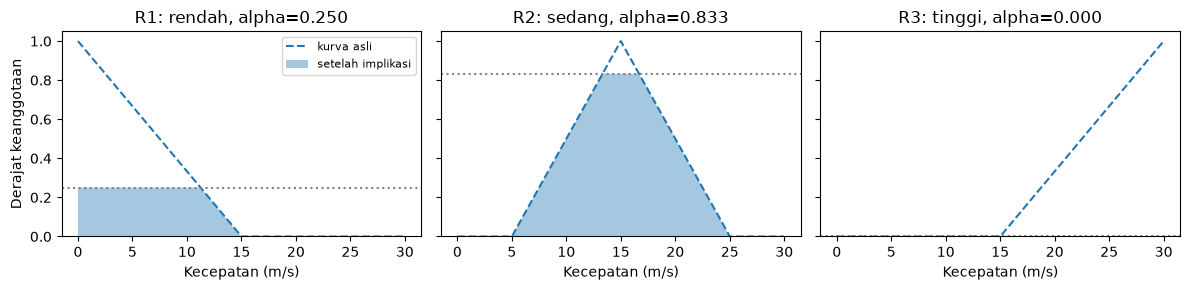

In [4]:
speed_grid = np.linspace(0, 30, 3001)  # langkah 0,01 m/s
output_curves = {
    "rendah": np.array([linear_down(z, 0, 15) for z in speed_grid]),
    "sedang": np.array([triangular(z, 5, 15, 25) for z in speed_grid]),
    "tinggi": np.array([linear_up(z, 15, 30) for z in speed_grid]),
}
clipped_outputs = np.array([
    np.minimum(alpha, output_curves[rule["output"]])
    for rule, alpha in zip(rules, strengths)
])
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, rule, alpha, clipped in zip(axes, rules, strengths, clipped_outputs):
    ax.plot(speed_grid, output_curves[rule["output"]], "--", label="kurva asli")
    ax.fill_between(speed_grid, clipped, alpha=0.4, label="setelah implikasi")
    ax.axhline(alpha, color="gray", linestyle=":")
    ax.set_title(f'{rule["aturan"]}: {rule["output"]}, alpha={alpha:.3f}')
    ax.set_xlabel("Kecepatan (m/s)")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("Derajat keanggotaan")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Kurva rendah terpotong pada 0,25 dan kurva sedang pada sekitar 0,8333. Keluaran R3 seluruhnya nol. Kurva hasil R1/R2 masih mencakup banyak kecepatan, sehingga kita belum mempunyai satu angka rekomendasi.

---
## 2.5 Langkah 4: agregasi keluaran aturan

### Penjelasan

**Agregasi** menggabungkan kurva keluaran aturan dengan maksimum pada **setiap titik kecepatan**:

$$\mu_{\mathrm{agg}}(z)=\max_i\mu'_i(z).$$

Pada $z=10$ m/s, kontribusi R1, R2, dan R3 adalah [0,25; 0,5; 0], sehingga derajat gabungannya 0,5. Pada titik lain, aturan yang membentuk batas atas dapat berbeda. Oleh karena itu, mengambil satu aturan dengan alpha terbesar saja tidak sama dengan melakukan agregasi.

![Pemotongan dan agregasi dua aturan pada halaman 45 Fuzzy Logic complete.pdf](img/complete-45-mamdani.png)

Dua operasi min/max mempunyai tempat berbeda: min pada implikasi membatasi **satu** kurva, sedangkan max pada agregasi menggabungkan kurva **antaraturan**.

### Contoh penerapan

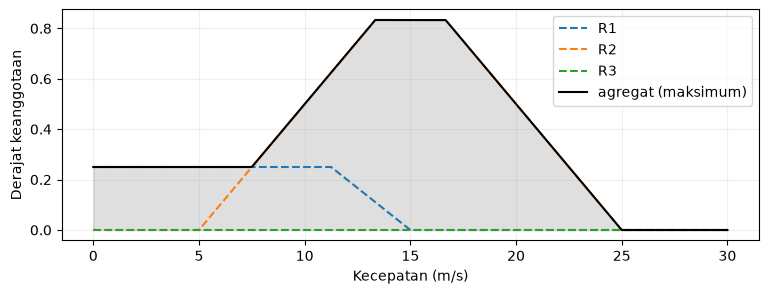

Kontribusi pada 10 m/s: [0.25 0.5  0.  ]
Agregat pada 10 m/s: 0.5


In [5]:
aggregated = np.maximum.reduce(clipped_outputs)
plt.figure(figsize=(9, 3))
for rule, clipped in zip(rules, clipped_outputs):
    plt.plot(speed_grid, clipped, "--", label=rule["aturan"])
plt.fill_between(speed_grid, aggregated, color="gray", alpha=0.25)
plt.plot(speed_grid, aggregated, color="black", label="agregat (maksimum)")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
index_10 = np.argmin(abs(speed_grid - 10))
print("Kontribusi pada 10 m/s:", clipped_outputs[:, index_10])
print("Agregat pada 10 m/s:", aggregated[index_10])

Batas atas daerah abu-abu adalah satu himpunan fuzzy keluaran. Bagian kecepatan rendah dari R1 tetap ikut membentuk daerah ini. Penjumlahan kurva bukan operator agregasi yang digunakan dalam contoh.

---
## 2.6 Langkah 5: defuzzifikasi dengan centroid

### Penjelasan

Sistem yang membutuhkan angka tindakan perlu mengubah kurva agregat menjadi **output crisp**. Metode **centroid** atau *center of gravity* (COG/COA) mencari titik keseimbangan luas di bawah kurva:

$$z^*=\frac{\int_{z_{\min}}^{z_{\max}}z\,\mu_{\mathrm{agg}}(z)\,dz}
{\int_{z_{\min}}^{z_{\max}}\mu_{\mathrm{agg}}(z)\,dz}.$$

Penyebut adalah luas total; pembilang adalah momen luas terhadap titik nol. Daerah pada nilai $z$ lebih besar menarik titik keseimbangan ke kanan. Semua bagian kurva berkontribusi, termasuk bagian yang derajatnya kecil.

Kode memakai integrasi numerik trapesium pada grid berjarak 0,01 m/s. Nilai yang diperoleh merupakan pendekatan centroid kurva kontinu. Pada domain diskret dengan bobot titik yang sama, bentuknya menjadi $\sum_j z_j\mu_j/\sum_j\mu_j$.

**Jangan langsung merata-ratakan puncak label menggunakan alpha.** Pada Mamdani max-min, bentuk, luas, dan tumpang tindih kurva terpotong ikut menentukan centroid. Contoh ringkas PDF halaman 75 dan 86 memakai nilai perwakilan kategori; rumus ringkas itu tidak secara umum sama dengan centroid kurva agregat yang dihitung di sini.

Metode lain dapat memberi hasil berbeda: **bisector (BOA)** membagi luas menjadi dua sama besar; **MOM** merata-ratakan posisi yang mencapai maksimum; **SOM** mengambil posisi maksimum terkecil; **LOM** mengambil yang terbesar. Centroid adalah titik keseimbangan, sehingga tidak harus membagi luas menjadi dua sama besar.

### Contoh penerapan

Luas agregat: 11.2847
Rekomendasi kecepatan: 13.36 m/s


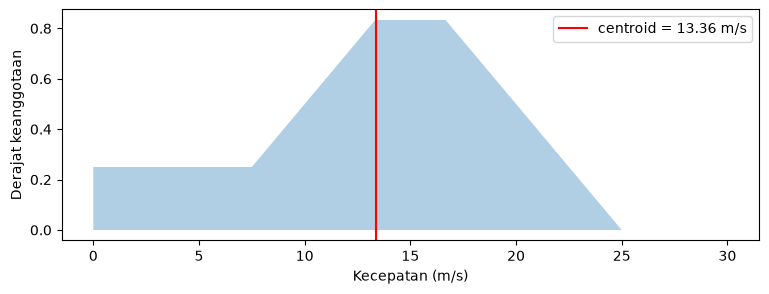

In [6]:
def integrate_trapezoids(values, grid):
    # Luas setiap trapesium = lebar * rata-rata tinggi kedua ujung.
    return float(np.sum(np.diff(grid) * (values[:-1] + values[1:]) / 2))

def centroid(grid, membership):
    area = integrate_trapezoids(membership, grid)
    if area <= 0:
        raise ValueError("Tidak ada keluaran aktif; periksa domain dan cakupan aturan.")
    moment = integrate_trapezoids(grid * membership, grid)
    return moment / area

crisp_speed = centroid(speed_grid, aggregated)
print(f"Luas agregat: {integrate_trapezoids(aggregated, speed_grid):.4f}")
print(f"Rekomendasi kecepatan: {crisp_speed:.2f} m/s")
plt.figure(figsize=(9, 3))
plt.fill_between(speed_grid, aggregated, alpha=0.35)
plt.axvline(crisp_speed, color="red", label=f"centroid = {crisp_speed:.2f} m/s")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.show()

Hasilnya sekitar **13,36 m/s**, di bawah pusat label sedang (15 m/s), karena kontribusi kecepatan rendah ikut menarik centroid ke kiri. Nilai ini berasal dari rancangan fungsi output praktikum, sehingga tidak ditujukan untuk menyamai angka kecepatan pada slide. Output crisp juga tidak harus sama dengan salah satu puncak fungsi keanggotaan.

---
## 2.7 Pengayaan: pemotongan dan penskalaan

### Penjelasan

PDF halaman 42-47 membandingkan pemotongan (*truncated*) dan penskalaan (*scaled*) konsekuen. Pada pemotongan, implikasinya $\min(\alpha_i,\mu_{C_i}(z))$. Pada penskalaan, implikasinya berupa perkalian:

$$\mu'_i(z)=\alpha_i\,\mu_{C_i}(z).$$

Dengan penskalaan, semua tinggi kurva dikalikan alpha. Misalnya, untuk alpha = 0,25 dan derajat kurva asli = 0,4, hasil pemotongan adalah 0,25, sedangkan hasil penskalaan adalah 0,1. Bentuk relatif kurva dipertahankan oleh penskalaan.

Pada perbandingan berikut, input, kekuatan aturan, fungsi output, dan agregasi max tetap sama; yang dibandingkan adalah pilihan **implikasi**. Perkalian pada implikasi berbeda letaknya dari perkalian sebagai alternatif operator AND pada anteseden.

### Contoh penerapan

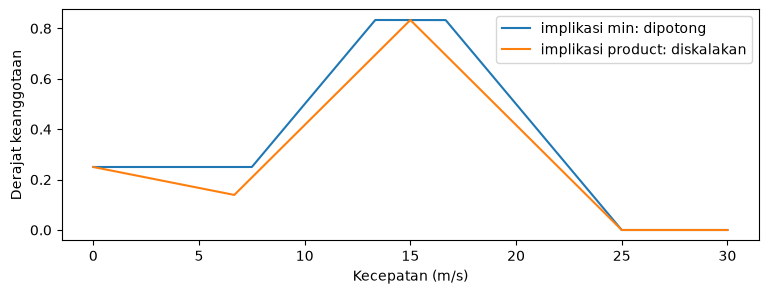

min + max        13.361538
product + max    13.475262
Name: centroid (m/s), dtype: float64

In [7]:
scaled_outputs = np.array([
    alpha * output_curves[rule["output"]]
    for rule, alpha in zip(rules, strengths)
])
scaled_aggregate = np.maximum.reduce(scaled_outputs)
plt.figure(figsize=(9, 3))
plt.plot(speed_grid, aggregated, label="implikasi min: dipotong")
plt.plot(speed_grid, scaled_aggregate, label="implikasi product: diskalakan")
plt.xlabel("Kecepatan (m/s)")
plt.ylabel("Derajat keanggotaan")
plt.legend()
plt.show()
display(pd.Series({
    "min + max": centroid(speed_grid, aggregated),
    "product + max": centroid(speed_grid, scaled_aggregate),
}, name="centroid (m/s)"))

Pemotongan menghasilkan sekitar **13,36 m/s**, sedangkan penskalaan menghasilkan sekitar **13,48 m/s**. Perubahan bentuk daerah keluaran dapat menggeser centroid walaupun alpha sama. Karena itu, saat melaporkan hasil inferensi, sebutkan fungsi keanggotaan, operator anteseden, implikasi, agregasi, dan metode defuzzifikasinya.

---
## 2.8 Aplikasi utuh: menguji beberapa jarak

### Penjelasan

Gabungkan langkah-langkah tadi ke satu fungsi. Fungsi ini mengembalikan derajat input, kekuatan aturan, kurva agregat, dan output crisp sehingga hasil antara tetap dapat diperiksa.

Sebelum menjalankan kode, buat prediksi: pada jarak 0 m hanya aturan rendah aktif; pada 5 m hanya aturan sedang aktif; pada 10 m hanya aturan tinggi aktif. Karena fungsi rendah memiliki luas pada rentang 0-15 m/s, centroidnya bukan otomatis 0 m/s. Inilah contoh bagaimana definisi himpunan output memengaruhi perilaku sistem.

Periksa juga input di sekitar daerah tumpang tindih. Perubahan kecepatan ditentukan bersama oleh fungsi input, bentuk output, dan interaksi aturan. Pada masalah nyata, definisi ini perlu disesuaikan dengan kebutuhan tindakan, misalnya kebutuhan berhenti ketika jarak sangat dekat.

### Contoh penerapan

,jarak (m),dekat,sedang,jauh,kecepatan (m/s)
0,0.0,1.00,0.0000,0.00,5.0000
1,2.5,0.75,0.5000,0.00,10.3805
2,3.5,0.25,0.8333,0.00,13.3615
3,5.0,0.00,1.0000,0.00,15.0000
4,7.5,0.00,0.5000,0.75,19.6195
5,10.0,0.00,0.0000,1.00,25.0000


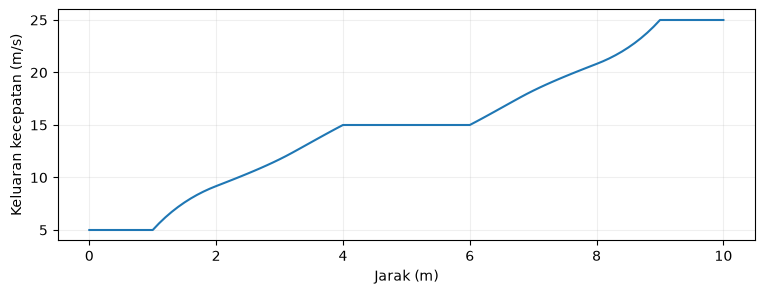

In [8]:
def mamdani_speed(distance):
    degrees = fuzzify_distance(distance)
    alphas = np.array([degrees[rule["input"]] for rule in rules])
    outputs = np.array([
        np.minimum(alpha, output_curves[rule["output"]])
        for rule, alpha in zip(rules, alphas)
    ])
    combined = np.maximum.reduce(outputs)
    return {
        "input_degrees": degrees,
        "strengths": alphas,
        "aggregated": combined,
        "speed": centroid(speed_grid, combined),
    }

rows = []
for x in [0, 2.5, 3.5, 5, 7.5, 10]:
    result = mamdani_speed(x)
    rows.append({"jarak (m)": x, **result["input_degrees"], "kecepatan (m/s)": result["speed"]})
display(pd.DataFrame(rows).round(4))
trial_distances = np.linspace(0, 10, 101)
plt.figure(figsize=(9, 3))
plt.plot(trial_distances, [mamdani_speed(x)["speed"] for x in trial_distances])
plt.xlabel("Jarak (m)")
plt.ylabel("Keluaran kecepatan (m/s)")
plt.grid(alpha=0.2)
plt.show()

Pada jarak 0, 5, dan 10 m, keluaran berturut-turut mendekati **5, 15, dan 25 m/s**. Saat beberapa aturan aktif, centroid memperhitungkan seluruh daerah gabungan. Fungsi menolak input di luar 0-10 m, dan perhitungan centroid menolak luas nol; hasil tidak diganti sembarang angka ketika aturan tidak mencakup input.

---
## Latihan Soal

Selesaikan tiga kasus berikut dengan **metode Mamdani**. Parameter dan aturan merupakan rancangan simulasi untuk latihan. Setiap kasus sudah menyediakan input crisp, domain, fungsi keanggotaan, serta basis aturan agar dapat diselesaikan sampai memperoleh output numerik.

**Ketentuan untuk semua kasus:** gunakan AND = min, OR = max, NOT = $1-\mu$, implikasi = min, agregasi = max, dan defuzzifikasi = centroid. Operator OR dan NOT digunakan jika tercantum pada aturan. Evaluasi fungsi keluaran hanya pada domain output yang diberikan.

Untuk setiap kasus, kerjakan tahapan berikut:

1. Gambarkan fungsi keanggotaan input dan output, lengkap dengan nama label dan satuannya.
2. Hitung fuzzifikasi input secara manual dan sajikan derajatnya dalam tabel.
3. Hitung kekuatan aktivasi setiap aturan; tunjukkan aturan yang aktif maupun tidak aktif.
4. Terapkan implikasi min pada kurva konsekuen setiap aturan, lalu gabungkan seluruh hasilnya dengan max.
5. Gambarkan kurva agregat dan hitung centroid menggunakan grid output dengan jarak antartitik **0,1**, termasuk kedua batas domain. Gunakan integrasi trapesium seperti fungsi `centroid` pada materi.
6. Sajikan output crisp dengan satuan yang sesuai, lalu jelaskan hubungannya dengan input dan aturan yang dominan.

Gunakan fungsi keanggotaan dari `membership.py` dan fungsi `centroid` yang telah tersedia. Susun perhitungan inferensi sesuai data setiap kasus. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan. Hint tersedia sebagai petunjuk pengerjaan tanpa jawaban akhir.

### Soal 1 - Kasus pengaturan kecepatan kipas

Sebuah pengendali menentukan persentase kecepatan kipas berdasarkan suhu ruangan. Pada saat pengukuran, suhu ruangan adalah **28°C**. Tentukan rekomendasi kecepatan kipas menggunakan seluruh tahapan Mamdani.

**Input:** suhu $T$ dengan domain [10,45] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Nyaman | `triangular(T, 20, 30, 40)` |
| Panas | `linear_up(T, 30, 40)` |

**Output:** kecepatan kipas $z$ dengan domain [0,100] persen dari kecepatan maksimum.

| Label kecepatan | Fungsi keanggotaan |
|---|---|
| Lambat | `linear_down(z, 0, 50)` |
| Sedang | `triangular(z, 25, 50, 75)` |
| Cepat | `linear_up(z, 50, 100)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF suhu Sejuk | THEN kecepatan Lambat |
| R2 | IF suhu Nyaman | THEN kecepatan Sedang |
| R3 | IF suhu Panas | THEN kecepatan Cepat |

Setelah menyelesaikan input 28°C, ulangi perhitungan untuk **36°C** dengan model yang sama. Bandingkan aturan aktif, bentuk kurva agregat, dan output crisp kedua kondisi. Jelaskan apakah perubahan rekomendasinya sesuai dengan maksud basis aturan.

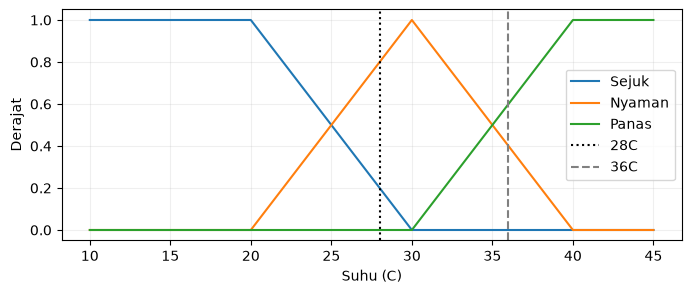

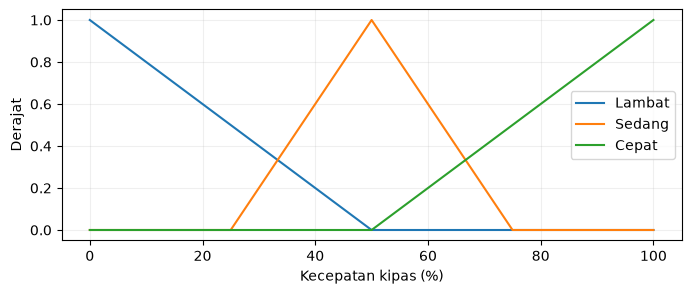

T=28: sejuk=0.2000 nyaman=0.8000 panas=0.0000
T=36: sejuk=0.0000 nyaman=0.4000 panas=0.6000
T=28 -> R1=0.2000 R2=0.8000 R3=0.0000
T=36 -> R1=0.0000 R2=0.4000 R3=0.6000
28C: R1+R2 aktif, R3 mati. 36C: R2+R3 aktif, R1 mati.
T=28: centroid = 43.25 %


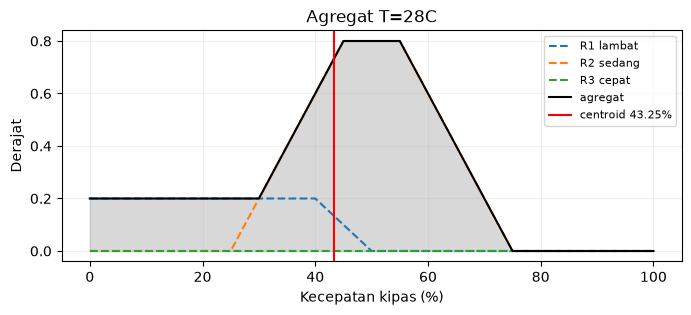

T=36: centroid = 68.34 %


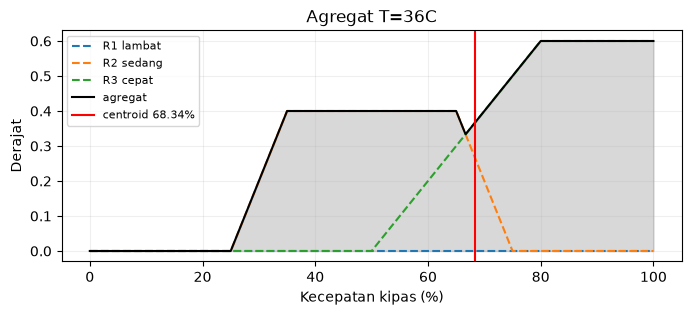

In [9]:
# fungsi bantuan centroid (sama kayak di materi)
def luas_trapesium(vals, grid):
    return float(np.sum(np.diff(grid) * (vals[:-1] + vals[1:]) / 2))

def centroid(grid, mu):
    luas = luas_trapesium(mu, grid)
    momen = luas_trapesium(grid * mu, grid)
    return momen / luas

# Soal 1 - kipas, input suhu 28C dan 36C
# domain input [10,45], output [0,100]

# 1) gambar fungsi input
t_grid = np.linspace(10, 45, 351)
plt.figure(figsize=(8, 3))
plt.plot(t_grid, [linear_down(t, 20, 30) for t in t_grid], label="Sejuk")
plt.plot(t_grid, [triangular(t, 20, 30, 40) for t in t_grid], label="Nyaman")
plt.plot(t_grid, [linear_up(t, 30, 40) for t in t_grid], label="Panas")
plt.axvline(28, color="black", linestyle=":", label="28C")
plt.axvline(36, color="gray", linestyle="--", label="36C")
plt.xlabel("Suhu (C)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# gambar fungsi output
z_grid = np.arange(0, 100 + 1e-9, 0.1)  # step 0.1 sesuai ketentuan
lambat = np.array([linear_down(z, 0, 50) for z in z_grid])
sedang_out = np.array([triangular(z, 25, 50, 75) for z in z_grid])
cepat = np.array([linear_up(z, 50, 100) for z in z_grid])
plt.figure(figsize=(8, 3))
plt.plot(z_grid, lambat, label="Lambat")
plt.plot(z_grid, sedang_out, label="Sedang")
plt.plot(z_grid, cepat, label="Cepat")
plt.xlabel("Kecepatan kipas (%)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 2) fuzzifikasi manual
# 28C: sejuk (30-28)/10=0.2, nyaman (28-20)/10=0.8, panas 0 (28<30)
# 36C: sejuk 0, nyaman (40-36)/10=0.4, panas (36-30)/10=0.6
for T in [28, 36]:
    s = linear_down(T, 20, 30)
    n = triangular(T, 20, 30, 40)
    p = linear_up(T, 30, 40)
    print(f"T={T}: sejuk={s:.4f} nyaman={n:.4f} panas={p:.4f}")

def mamdani_kipas(T):
    a1 = linear_down(T, 20, 30)
    a2 = triangular(T, 20, 30, 40)
    a3 = linear_up(T, 30, 40)
    c1 = np.minimum(a1, lambat)
    c2 = np.minimum(a2, sedang_out)
    c3 = np.minimum(a3, cepat)
    agg = np.maximum.reduce([c1, c2, c3])
    return (a1, a2, a3), (c1, c2, c3), agg, centroid(z_grid, agg)

# 3) alpha tiap aturan
for T in [28, 36]:
    alphas, _, _, _ = mamdani_kipas(T)
    print(f"T={T} -> R1={alphas[0]:.4f} R2={alphas[1]:.4f} R3={alphas[2]:.4f}")
print("28C: R1+R2 aktif, R3 mati. 36C: R2+R3 aktif, R1 mati.")

# 4-5) agregat + centroid
for T in [28, 36]:
    alphas, clips, agg, crisp = mamdani_kipas(T)
    print(f"T={T}: centroid = {crisp:.2f} %")
    plt.figure(figsize=(8, 3))
    plt.plot(z_grid, clips[0], "--", label="R1 lambat")
    plt.plot(z_grid, clips[1], "--", label="R2 sedang")
    plt.plot(z_grid, clips[2], "--", label="R3 cepat")
    plt.fill_between(z_grid, agg, alpha=0.3, color="gray")
    plt.plot(z_grid, agg, color="black", label="agregat")
    plt.axvline(crisp, color="red", label=f"centroid {crisp:.2f}%")
    plt.xlabel("Kecepatan kipas (%)")
    plt.ylabel("Derajat")
    plt.title(f"Agregat T={T}C")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.2)
    plt.show()


**Jawaban Soal 1 - kipas**

Hasilnya: 28C jadi sekitar **43,25%**, 36C jadi sekitar **68,34%**.

Masuk akal karena aturannya "makin panas makin kenceng". Di 28C yang dominan R2 (nyaman 0,8, dipotong di 0,8) plus sedikit R1 (sejuk 0,2, kepotong rendah di kiri), jadi agregatnya numpuk di tengah-kiri, centroid ketarik ke bawah dari puncak sedang (50%) ke 43%. Di 36C yang dominan R3 (panas 0,6) lawan R2 (0,4), jadi agregatnya geser ke kanan, centroid 68% (di antara sedang 50% dan cepat yang penuh di 100%). Jadi perubahan rekomendasinya sesuai maksud aturan: suhu naik, kipas naik. Saya pakai grid 0,1 dari 0 sampai 100 dan integrasi trapesium kayak fungsi `centroid` di materi.


<details>
<summary>Klik untuk melihat hint</summary>

Letakkan suhu input pada masing-masing kurva sebelum memilih cabang rumus. Karena setiap aturan hanya mempunyai satu syarat, telusuri langsung derajat label pada antesedennya. Untuk membandingkan kedua kondisi, perhatikan posisi daerah keluaran yang terbentuk setelah pemotongan, bukan hanya tinggi maksimum kurvanya.

</details>

### Soal 2 - Kasus penentuan durasi pencucian

Sebuah mesin cuci menentukan durasi pencucian dari tingkat kekotoran dan berat pakaian. Sensor menunjukkan **indeks kekotoran 65** dan **berat pakaian 6,5 kg**. Tentukan durasi pencucian dengan Mamdani menggunakan seluruh tahapan pada petunjuk latihan.

**Input pertama:** indeks kekotoran $k$ dengan domain [0,100]. Indeks 0 menyatakan tingkat kekotoran terendah dan 100 tertinggi; indeks ini tidak memiliki satuan fisik.

| Label kekotoran | Fungsi keanggotaan |
|---|---|
| Rendah | `linear_down(k, 20, 50)` |
| Sedang | `trapezoidal(k, 20, 40, 60, 80)` |
| Tinggi | `linear_up(k, 50, 80)` |

**Input kedua:** berat pakaian $b$ dengan domain [0,10] kg.

| Label berat | Fungsi keanggotaan |
|---|---|
| Ringan | `linear_down(b, 2, 5)` |
| Sedang | `triangular(b, 2, 5, 8)` |
| Berat | `linear_up(b, 5, 8)` |

**Output:** durasi pencucian $z$ dengan domain [0,60] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 10, 30)` |
| Normal | `trapezoidal(z, 15, 25, 35, 45)` |
| Lama | `linear_up(z, 30, 50)` |

**Basis aturan:** setiap sel tabel menyatakan konsekuen untuk kombinasi **kekotoran AND berat pakaian**. Baris menunjukkan label kekotoran dan kolom menunjukkan label berat pakaian, sehingga terdapat sembilan aturan.

| Kekotoran / Berat pakaian | Ringan | Sedang | Berat |
|---|---|---|---|
| Rendah | Singkat | Singkat | Normal |
| Sedang | Singkat | Normal | Lama |
| Tinggi | Normal | Lama | Lama |

Beri nama R1-R9 secara berurutan dari kiri ke kanan pada setiap baris, mulai baris Rendah. Sajikan alpha untuk kesembilan aturan. Bila beberapa aturan memiliki konsekuen yang sama, tunjukkan bagaimana kontribusinya digabungkan.

Setelah memperoleh durasi untuk kondisi awal, ulangi perhitungan dengan **indeks kekotoran 35** dan berat tetap **6,5 kg**. Bandingkan kedua durasi dan jelaskan pengaruh perubahan input melalui aturan yang aktif.

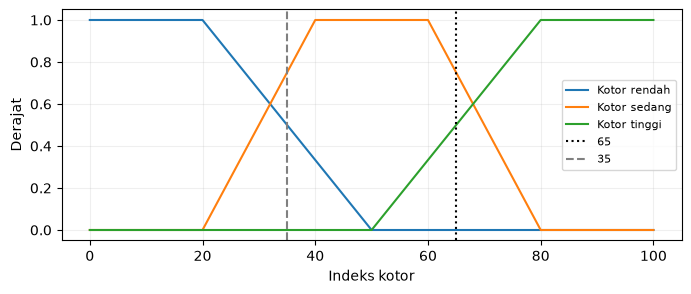

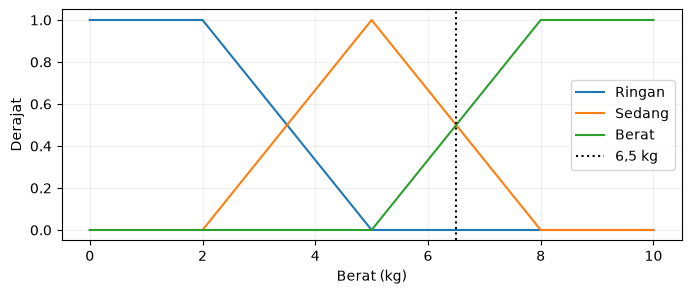

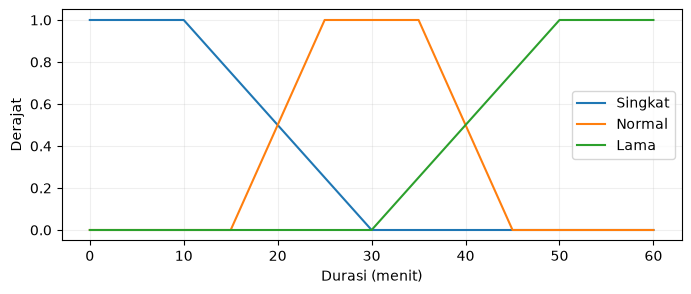

=== k=65, b=6.5 ===
kotor: {'Rendah': 0.0, 'Sedang': 0.75, 'Tinggi': 0.5}
berat: {'Ringan': 0.0, 'Sedang': 0.5, 'Berat': 0.5}
R1 (Rendah+Ringan->Singkat): 0.0000
R2 (Rendah+Sedang->Singkat): 0.0000
R3 (Rendah+Berat->Normal): 0.0000
R4 (Sedang+Ringan->Singkat): 0.0000
R5 (Sedang+Sedang->Normal): 0.5000
R6 (Sedang+Berat->Lama): 0.5000
R7 (Tinggi+Ringan->Normal): 0.0000
R8 (Tinggi+Sedang->Lama): 0.5000
R9 (Tinggi+Berat->Lama): 0.5000
centroid = 38.73 menit


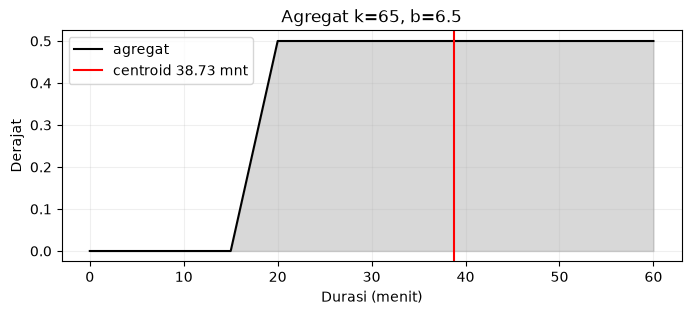

=== k=35, b=6.5 ===
kotor: {'Rendah': 0.5, 'Sedang': 0.75, 'Tinggi': 0.0}
berat: {'Ringan': 0.0, 'Sedang': 0.5, 'Berat': 0.5}
R1 (Rendah+Ringan->Singkat): 0.0000
R2 (Rendah+Sedang->Singkat): 0.5000
R3 (Rendah+Berat->Normal): 0.5000
R4 (Sedang+Ringan->Singkat): 0.0000
R5 (Sedang+Sedang->Normal): 0.5000
R6 (Sedang+Berat->Lama): 0.5000
R7 (Tinggi+Ringan->Normal): 0.0000
R8 (Tinggi+Sedang->Lama): 0.0000
R9 (Tinggi+Berat->Lama): 0.0000
centroid = 30.00 menit


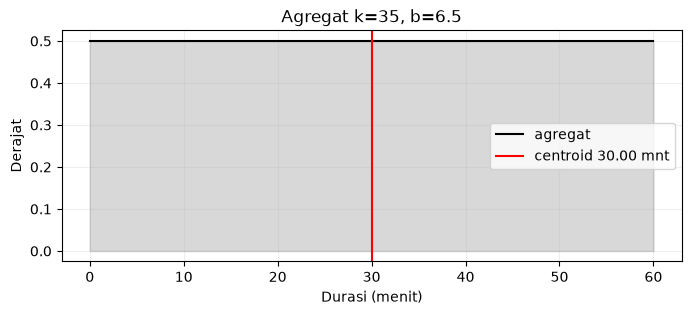

In [10]:
# fungsi bantuan centroid (sama kayak di materi)
def luas_trapesium(vals, grid):
    return float(np.sum(np.diff(grid) * (vals[:-1] + vals[1:]) / 2))

def centroid(grid, mu):
    luas = luas_trapesium(mu, grid)
    momen = luas_trapesium(grid * mu, grid)
    return momen / luas

# Soal 2 - mesin cuci, 2 input: kotor (0-100) dan berat (0-10 kg)
z2 = np.arange(0, 60 + 1e-9, 0.1)
singkat = np.array([linear_down(v, 10, 30) for v in z2])
normal = np.array([trapezoidal(v, 15, 25, 35, 45) for v in z2])
lama = np.array([linear_up(v, 30, 50) for v in z2])

# 1) gambar input
k_grid = np.linspace(0, 100, 401)
plt.figure(figsize=(8, 3))
plt.plot(k_grid, [linear_down(k, 20, 50) for k in k_grid], label="Kotor rendah")
plt.plot(k_grid, [trapezoidal(k, 20, 40, 60, 80) for k in k_grid], label="Kotor sedang")
plt.plot(k_grid, [linear_up(k, 50, 80) for k in k_grid], label="Kotor tinggi")
plt.axvline(65, color="black", linestyle=":", label="65")
plt.axvline(35, color="gray", linestyle="--", label="35")
plt.xlabel("Indeks kotor")
plt.ylabel("Derajat")
plt.legend(fontsize=8)
plt.grid(alpha=0.2)
plt.show()

b_grid = np.linspace(0, 10, 401)
plt.figure(figsize=(8, 3))
plt.plot(b_grid, [linear_down(b, 2, 5) for b in b_grid], label="Ringan")
plt.plot(b_grid, [triangular(b, 2, 5, 8) for b in b_grid], label="Sedang")
plt.plot(b_grid, [linear_up(b, 5, 8) for b in b_grid], label="Berat")
plt.axvline(6.5, color="black", linestyle=":", label="6,5 kg")
plt.xlabel("Berat (kg)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# gambar output
plt.figure(figsize=(8, 3))
plt.plot(z2, singkat, label="Singkat")
plt.plot(z2, normal, label="Normal")
plt.plot(z2, lama, label="Lama")
plt.xlabel("Durasi (menit)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# aturan R1-R9: baris = kotor (Rendah, Sedang, Tinggi), kolom = berat (Ringan, Sedang, Berat)
kons = [["Singkat", "Singkat", "Normal"], ["Singkat", "Normal", "Lama"], ["Normal", "Lama", "Lama"]]
lk_list = ["Rendah", "Sedang", "Tinggi"]
lb_list = ["Ringan", "Sedang", "Berat"]
cmap = {"Singkat": singkat, "Normal": normal, "Lama": lama}

def fuzz_kotor(k):
    return {"Rendah": linear_down(k, 20, 50), "Sedang": trapezoidal(k, 20, 40, 60, 80), "Tinggi": linear_up(k, 50, 80)}

def fuzz_berat(b):
    return {"Ringan": linear_down(b, 2, 5), "Sedang": triangular(b, 2, 5, 8), "Berat": linear_up(b, 5, 8)}

def mamdani_cuci(k, b):
    fk, fb = fuzz_kotor(k), fuzz_berat(b)
    alphas, outs = [], []
    n = 0
    for i, lk in enumerate(lk_list):
        for j, lb in enumerate(lb_list):
            n += 1
            a = min(fk[lk], fb[lb])  # AND = min
            alphas.append((f"R{n}", lk, lb, kons[i][j], a))
            outs.append(np.minimum(a, cmap[kons[i][j]]))
    agg = np.maximum.reduce(outs)
    return fk, fb, alphas, outs, agg, centroid(z2, agg)

# kondisi awal k=65, b=6.5
# manual: kotor rendah (50-65 negatif -> 0), sedang sisi turun (80-65)/20=0.75, tinggi (65-50)/30=0.5
# berat ringan 0 (6.5>5), sedang (8-6.5)/3=0.5, berat (6.5-5)/3=0.5
for k, b in [(65, 6.5), (35, 6.5)]:
    fk, fb, alphas, outs, agg, crisp = mamdani_cuci(k, b)
    print(f"=== k={k}, b={b} ===")
    print("kotor:", {b_: round(v, 4) for b_, v in fk.items()})
    print("berat:", {b_: round(v, 4) for b_, v in fb.items()})
    for r, lk, lb, ko, a in alphas:
        print(f"{r} ({lk}+{lb}->{ko}): {a:.4f}")
    print(f"centroid = {crisp:.2f} menit")
    plt.figure(figsize=(8, 3))
    plt.plot(z2, agg, color="black", label="agregat")
    plt.fill_between(z2, agg, alpha=0.3, color="gray")
    plt.axvline(crisp, color="red", label=f"centroid {crisp:.2f} mnt")
    plt.xlabel("Durasi (menit)")
    plt.ylabel("Derajat")
    plt.title(f"Agregat k={k}, b={b}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


**Jawaban Soal 2 - mesin cuci**

Kondisi awal (65; 6,5) hasilnya sekitar **38,73 menit**, kondisi kedua (35; 6,5) hasilnya **30,00 menit**. Jadi pas kotornya turun, durasinya ikut turun, sesuai aturan (kotor ringan cenderung singkat/normal).

Detailnya: di kondisi awal yang aktif cuma 4 aturan (R5=0,5 normal, R6=0,5 lama, R8=0,5 lama, R9=0,5 lama), sisanya 0 karena kotor rendahnya 0 dan berat ringannya 0. Karena dua aturan lama aktif penuh (0,5), agregatnya ketarik ke kanan. Kalau beberapa aturan konsekuennya sama (misal R6, R8, R9 sama-sama Lama), saya nggak jumlahin alphanya, tapi masing-masing dipotong pakai min dulu baru digabung pakai max di tiap titik z, jadi yang diambil batas atasnya. Di kondisi kedua, kotor rendah jadi 0,5 sehingga R2 (singkat 0,5) dan R3 (normal 0,5) ikut aktif, agregatnya jadi simetris di tengah dan centroidnya pas 30 menit.


<details>
<summary>Klik untuk melihat hint</summary>

Hitung derajat kekotoran dan berat secara terpisah, lalu pasangkan sesuai baris dan kolom tabel aturan. Gunakan operator AND pada setiap pasangan derajat. Saat beberapa aturan mengarah ke label output yang sama, kembali ke definisi agregasi max pada setiap titik domain; hindari menjumlahkan alpha. Gunakan grid durasi yang sama saat membandingkan dua kondisi.

</details>

### Soal 3 - Kasus pengaturan durasi penyiraman

Sebuah sistem penyiraman menentukan lama penyiraman dari kelembapan tanah dan suhu udara. Sensor menunjukkan **kelembapan tanah 45%** dan **suhu udara 32°C**. Tentukan durasi penyiraman dengan Mamdani. Kasus ini menggunakan AND, OR, dan NOT pada anteseden.

**Input pertama:** kelembapan tanah $h$ dengan domain [0,100] persen.

| Label kelembapan | Fungsi keanggotaan |
|---|---|
| Kering | `linear_down(h, 30, 60)` |
| Cukup | `trapezoidal(h, 30, 45, 60, 75)` |
| Basah | `linear_up(h, 60, 80)` |

**Input kedua:** suhu udara $T$ dengan domain [15,40] °C.

| Label suhu | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Panas | `linear_up(T, 25, 35)` |

**Output:** durasi penyiraman $z$ dengan domain [0,30] menit.

| Label durasi | Fungsi keanggotaan |
|---|---|
| Singkat | `linear_down(z, 0, 15)` |
| Sedang | `triangular(z, 5, 15, 25)` |
| Lama | `linear_up(z, 15, 30)` |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF tanah Kering AND suhu Panas | THEN durasi Lama |
| R2 | IF tanah Kering AND NOT (suhu Panas) | THEN durasi Sedang |
| R3 | IF tanah Cukup AND suhu Panas | THEN durasi Sedang |
| R4 | IF tanah Cukup AND NOT (suhu Panas) | THEN durasi Singkat |
| R5 | IF tanah Basah OR suhu Sejuk | THEN durasi Singkat |

Selesaikan seluruh tahapan Mamdani dan tuliskan operasi anteseden setiap aturan secara eksplisit. Untuk R2 dan R4, NOT hanya diterapkan pada kondisi suhu Panas.

Kemudian ubah **suhu menjadi 27°C**, dengan kelembapan tetap **45%**. Hitung ulang hasilnya. Bandingkan kekuatan R2, R4, dan R5 serta jelaskan kontribusinya terhadap perubahan durasi. Berdasarkan fungsi yang diberikan, periksa pula apakah label Sejuk selalu sama dengan NOT Panas pada seluruh domain suhu.

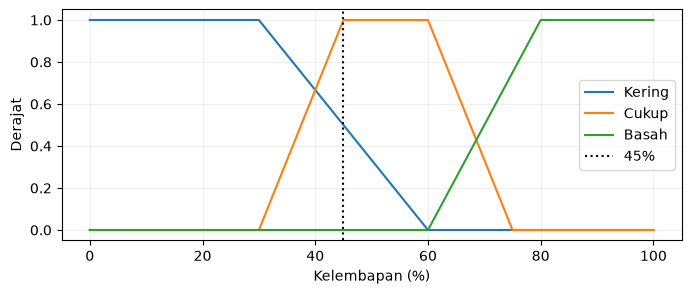

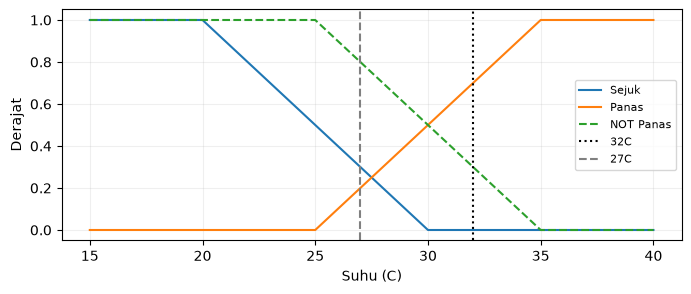

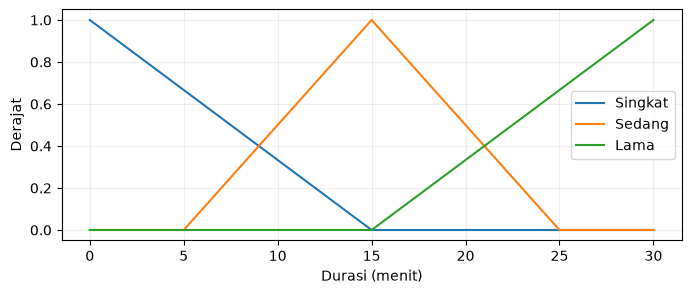

=== h=45%, T=32C ===
kering=0.5000 cukup=1.0000 basah=0.0000 sejuk=0.0000 panas=0.7000 NOTpanas=0.3000
R1=min(0.50,0.70)=0.5000 -> Lama
R2=min(0.50,0.30)=0.3000 -> Sedang
R3=min(1.00,0.70)=0.7000 -> Sedang
R4=min(1.00,0.30)=0.3000 -> Singkat
R5=max(0.00,0.00)=0.0000 -> Singkat
centroid = 16.23 menit


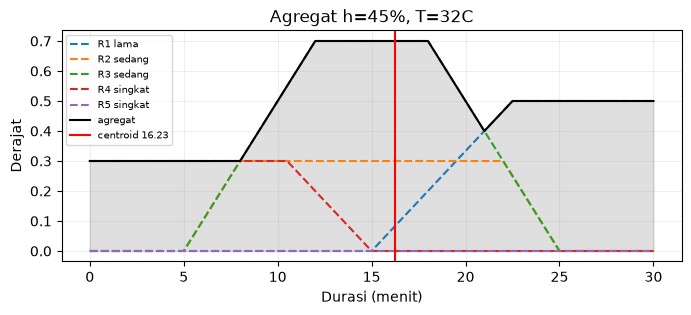

=== h=45%, T=27C ===
kering=0.5000 cukup=1.0000 basah=0.0000 sejuk=0.3000 panas=0.2000 NOTpanas=0.8000
R1=min(0.50,0.20)=0.2000 -> Lama
R2=min(0.50,0.80)=0.5000 -> Sedang
R3=min(1.00,0.20)=0.2000 -> Sedang
R4=min(1.00,0.80)=0.8000 -> Singkat
R5=max(0.00,0.30)=0.3000 -> Singkat
centroid = 11.71 menit


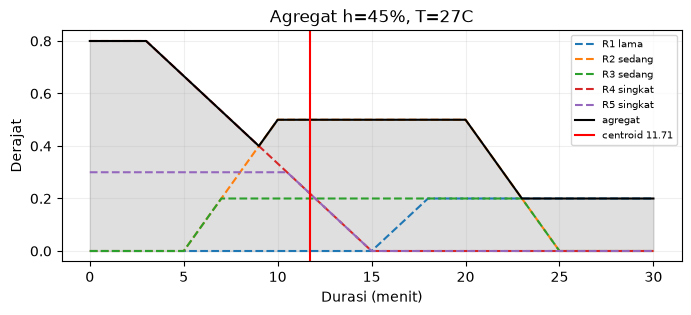

cek Sejuk vs NOT Panas:
T=15: sejuk=1.00 NOTpanas=1.00 sama? True
T=20: sejuk=1.00 NOTpanas=1.00 sama? True
T=25: sejuk=0.50 NOTpanas=1.00 sama? False
T=27: sejuk=0.30 NOTpanas=0.80 sama? False
T=30: sejuk=0.00 NOTpanas=0.50 sama? False
T=32: sejuk=0.00 NOTpanas=0.30 sama? False
T=35: sejuk=0.00 NOTpanas=0.00 sama? True
T=40: sejuk=0.00 NOTpanas=0.00 sama? True


In [11]:
# fungsi bantuan centroid (sama kayak di materi)
def luas_trapesium(vals, grid):
    return float(np.sum(np.diff(grid) * (vals[:-1] + vals[1:]) / 2))

def centroid(grid, mu):
    luas = luas_trapesium(mu, grid)
    momen = luas_trapesium(grid * mu, grid)
    return momen / luas

# Soal 3 - penyiraman, ada AND OR NOT
z3 = np.arange(0, 30 + 1e-9, 0.1)
psingkat = np.array([linear_down(v, 0, 15) for v in z3])
psedang = np.array([triangular(v, 5, 15, 25) for v in z3])
plama = np.array([linear_up(v, 15, 30) for v in z3])

# 1) gambar input
h_grid = np.linspace(0, 100, 401)
plt.figure(figsize=(8, 3))
plt.plot(h_grid, [linear_down(h, 30, 60) for h in h_grid], label="Kering")
plt.plot(h_grid, [trapezoidal(h, 30, 45, 60, 75) for h in h_grid], label="Cukup")
plt.plot(h_grid, [linear_up(h, 60, 80) for h in h_grid], label="Basah")
plt.axvline(45, color="black", linestyle=":", label="45%")
plt.xlabel("Kelembapan (%)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

t2_grid = np.linspace(15, 40, 251)
plt.figure(figsize=(8, 3))
plt.plot(t2_grid, [linear_down(t, 20, 30) for t in t2_grid], label="Sejuk")
plt.plot(t2_grid, [linear_up(t, 25, 35) for t in t2_grid], label="Panas")
plt.plot(t2_grid, [1 - linear_up(t, 25, 35) for t in t2_grid], label="NOT Panas", linestyle="--")
plt.axvline(32, color="black", linestyle=":", label="32C")
plt.axvline(27, color="gray", linestyle="--", label="27C")
plt.xlabel("Suhu (C)")
plt.ylabel("Derajat")
plt.legend(fontsize=8)
plt.grid(alpha=0.2)
plt.show()

# gambar output
plt.figure(figsize=(8, 3))
plt.plot(z3, psingkat, label="Singkat")
plt.plot(z3, psedang, label="Sedang")
plt.plot(z3, plama, label="Lama")
plt.xlabel("Durasi (menit)")
plt.ylabel("Derajat")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

def fuzz_h(h):
    return {"Kering": linear_down(h, 30, 60), "Cukup": trapezoidal(h, 30, 45, 60, 75), "Basah": linear_up(h, 60, 80)}

def fuzz_T(T):
    return {"Sejuk": linear_down(T, 20, 30), "Panas": linear_up(T, 25, 35)}

def mamdani_siram(h, T):
    fh, fT = fuzz_h(h), fuzz_T(T)
    kering, cukup, basah = fh["Kering"], fh["Cukup"], fh["Basah"]
    sejuk, panas = fT["Sejuk"], fT["Panas"]
    not_panas = 1 - panas
    a1 = min(kering, panas)  # R1: kering AND panas -> lama
    a2 = min(kering, not_panas)  # R2: kering AND NOT panas -> sedang
    a3 = min(cukup, panas)  # R3: cukup AND panas -> sedang
    a4 = min(cukup, not_panas)  # R4: cukup AND NOT panas -> singkat
    a5 = max(basah, sejuk)  # R5: basah OR sejuk -> singkat
    outs = [np.minimum(a1, plama), np.minimum(a2, psedang), np.minimum(a3, psedang), np.minimum(a4, psingkat), np.minimum(a5, psingkat)]
    agg = np.maximum.reduce(outs)
    return (kering, cukup, basah, sejuk, panas, not_panas), (a1, a2, a3, a4, a5), outs, agg, centroid(z3, agg)

# kondisi 1: h=45, T=32. manual: kering (60-45)/30=0.5, cukup 1.0 (45 di plateau), basah 0
# sejuk 0 (32>30), panas (32-25)/10=0.7, NOT panas 0.3
# kondisi 2: h=45, T=27. kering 0.5, cukup 1.0, basah 0, sejuk (30-27)/10=0.3, panas (27-25)/10=0.2, NOT 0.8
for h, T in [(45, 32), (45, 27)]:
    der, alphas, outs, agg, crisp = mamdani_siram(h, T)
    print(f"=== h={h}%, T={T}C ===")
    print(f"kering={der[0]:.4f} cukup={der[1]:.4f} basah={der[2]:.4f} sejuk={der[3]:.4f} panas={der[4]:.4f} NOTpanas={der[5]:.4f}")
    print(f"R1=min({der[0]:.2f},{der[4]:.2f})={alphas[0]:.4f} -> Lama")
    print(f"R2=min({der[0]:.2f},{der[5]:.2f})={alphas[1]:.4f} -> Sedang")
    print(f"R3=min({der[1]:.2f},{der[4]:.2f})={alphas[2]:.4f} -> Sedang")
    print(f"R4=min({der[1]:.2f},{der[5]:.2f})={alphas[3]:.4f} -> Singkat")
    print(f"R5=max({der[2]:.2f},{der[3]:.2f})={alphas[4]:.4f} -> Singkat")
    print(f"centroid = {crisp:.2f} menit")
    plt.figure(figsize=(8, 3))
    for o, nama in zip(outs, ["R1 lama", "R2 sedang", "R3 sedang", "R4 singkat", "R5 singkat"]):
        plt.plot(z3, o, "--", label=nama)
    plt.plot(z3, agg, color="black", label="agregat")
    plt.fill_between(z3, agg, alpha=0.25, color="gray")
    plt.axvline(crisp, color="red", label=f"centroid {crisp:.2f}")
    plt.xlabel("Durasi (menit)")
    plt.ylabel("Derajat")
    plt.title(f"Agregat h={h}%, T={T}C")
    plt.legend(fontsize=7)
    plt.grid(alpha=0.2)
    plt.show()

# cek Sejuk vs NOT Panas di seluruh domain, biar jawab pertanyaan terakhir
print("cek Sejuk vs NOT Panas:")
for T in [15, 20, 25, 27, 30, 32, 35, 40]:
    s = linear_down(T, 20, 30)
    p = linear_up(T, 25, 35)
    print(f"T={T}: sejuk={s:.2f} NOTpanas={1-p:.2f} sama? {abs(s-(1-p))<1e-9}")


**Jawaban Soal 3 - penyiraman**

Hasilnya: (45%; 32C) jadi sekitar **16,23 menit**, (45%; 27C) jadi sekitar **11,71 menit**. Jadi pas suhu turun, durasinya ikut turun, wajar karena tanahnya sama-sama cukup (1,0) tapi panasnya beda.

Yang berubah paling ngaruh itu R2, R4, R5. Di 32C: R2=0,3 (sedang), R4=0,3 (singkat), R5=0 (singkat mati total karena basah 0 dan sejuk 0). Di 27C: R2 naik jadi 0,5, R4 naik jadi 0,8, R5 ikut hidup 0,3 (karena sejuk 0,3). Jadi kontribusi singkat jadi gede banget (R4 0,8 + R5 0,3), agregat ketarik ke kiri, centroid turun 4,5 menit. R1 malah turun (0,5 ke 0,2) dan R3 turun (0,7 ke 0,2), jadi dorongan lama/sedang dari suhu panasnya melemah.

Terus Sejuk itu NGGAK selalu sama dengan NOT Panas. Buktinya di T=27: sejuk 0,3 tapi NOT panas 0,8; di T=30: sejuk 0 tapi NOT panas 0,5. Samanya cuma di ujung-ujung (T<=20 atau T>=35, dua-duanya 1 atau 0). Soalnya parameternya beda: sejuk turun di (20,30), panas naik di (25,35). Jadi walau bahasa sehari-harinya mirip, fungsinya beda dan nggak bisa disubstitusi. Saya tetap hitung Sejuk pakai `linear_down` sendiri, NOT Panas pakai `1 - linear_up`, sesuai perintah soal.


<details>
<summary>Klik untuk melihat hint</summary>

Evaluasi fungsi Panas terlebih dahulu sebelum menggunakan komplemennya. Hitung fungsi Sejuk secara terpisah berdasarkan parameternya; kesamaan makna dalam bahasa sehari-hari belum cukup untuk menyamakan dua fungsi. Setelah evaluasi AND/OR, semua aturan tetap melalui implikasi min dan agregasi max yang sama. Untuk memeriksa kesetaraan dua fungsi, bandingkan grafiknya pada seluruh domain, bukan hanya satu suhu.

</details>